# Imports, util functions, dictionary imports, input/output directories, vetting functions, vetting run on a single target and results

In [1]:
#imports
import gc
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from scipy.stats import pearsonr, binom, ttest_ind
from scipy.stats import chi2
from tess_transit.search import run_search, SearchConfig
from tess_transit.data.loader import load_pickle, get_lightcurve, available_sectors
from info import cadence_bounds
from scipy.stats import norm

plot = False

#constants
CADENCE_DURATION_DAYS = 2 / (24 * 60)

LC_DIR   = "/home/juliajos/tess_transit/data/lightcurves/"
LAB_DIR  = os.path.expanduser("~/tess_transit/data/lightcurves/")

#### injection parameters ###
TARGET_LC = "/home/juliajos/tess_transit/data/lightcurves/160602429.p"
TARGET_ID = os.path.splitext(os.path.basename(TARGET_LC))[0]
SECTORS     = [73, 74, 75, 76, 77]   # which sectors to use

INJECT_PERIOD   = 4320   # cadences — 6 days
INJECT_DURATION = 60     # cadences — 2 hours

#other functions 
def cadence_to_days(n_cadences):
    return n_cadences * CADENCE_DURATION_DAYS

def cadences_to_btjd(cadence_numbers):
    return cadence_numbers * (120 / 86400)

def epoch_to_btjd(epoch_cadences, duration_cadences):
    return (epoch_cadences + duration_cadences / 2) * (120 / 86400)

def in_transit_mask(time_bjd, period_days, t0_bjd, duration_days):
    """Boolean mask: True where time falls within a transit window."""
    if period_days <= 0 or duration_days <= 0:
        return np.zeros_like(time_bjd, dtype=bool)
    phase = ((time_bjd - t0_bjd + 0.5 * period_days) % period_days) - 0.5 * period_days
    return np.abs(phase) <= 0.5 * duration_days

#vetting test functions
def even_odd_phase_our_data(flux, time_btjd, period_days, t0_btjd, duration_days, plot_size=0.15, same_axes=False, plot=True):
    flux     = np.array(flux,     dtype=float)
    time_btjd = np.array(time_btjd, dtype=float)

    phase_full  = ((time_btjd - t0_btjd) % period_days) / period_days
    phase_folded = phase_full - np.round(phase_full)

    transit_num = np.floor((time_btjd - t0_btjd) / period_days).astype(int)

    half_window     = duration_days / (2 * period_days)
    in_transit      = np.abs(phase_folded) < half_window
    in_transit_odd  = in_transit & (transit_num % 2 == 1)
    in_transit_even = in_transit & (transit_num % 2 == 0)

    odd_depths  = 1 - flux[in_transit_odd]
    even_depths = 1 - flux[in_transit_even]
    odd_clean   = odd_depths[~np.isnan(odd_depths)]
    even_clean  = even_depths[~np.isnan(even_depths)]

    p_val = np.nan
    mean_odd = mean_even = np.nan
    if len(odd_clean) > 1 and len(even_clean) > 1:
        try:
            _, p_val  = ttest_ind(odd_clean, even_clean) #we use a t test to see if the difference is statistically significiant
            mean_odd  = float(np.nanmean(odd_depths))
            mean_even = float(np.nanmean(even_depths))
        except Exception as e:
            print(f"    t-test error: {e}")

    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        ax[0].plot(phase_odd,  flux, lw=0, color='navy',   marker='.', alpha=0.4)
        ax[1].plot(phase_even, flux, lw=0, color='maroon', marker='.', alpha=0.4)
        for a, label in zip(ax, ['ODD', 'EVEN']):
            a.set_xlabel('Phase')
            a.annotate(label, (0.3, np.nanmin(flux)), fontsize=14)
            a.set_xlim(-plot_size, plot_size)
        ax[0].set_ylabel('Normalized flux')
        plt.subplots_adjust(wspace=0.02)
        if not np.isnan(p_val):
            stat_text = (f"Odd depth:  {mean_odd:.4g}\n"
                         f"Even depth: {mean_even:.4g}\n"
                         f"p = {p_val:.2g}")
            ax[0].text(0.05, 0.95, stat_text, transform=ax[0].transAxes,
                       fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7))
        plt.suptitle("Even-Odd Test (INJECTED transit)", fontsize=13)
        plt.tight_layout()
        plt.show()

    return p_val


def calculate_enhanced_centroid_motion_pvalue(lc_flux, time_btjd, mom1, mom2, pos1, pos2, period_days, t0_btjd, duration_days,
    baseline_factor=3.0, sector=None, plot=True):
    time_btjd = np.asarray(time_btjd, dtype=float) #x points on a lightcurve
    lc_flux  = np.asarray(lc_flux,  dtype=float) #y points on a lightcurve
    mom1     = np.asarray(mom1,     dtype=float) #momentum based center of light
    mom2     = np.asarray(mom2,     dtype=float)
    pos1     = np.asarray(pos1,     dtype=float) #centroid fitted position center of light
    pos2     = np.asarray(pos2,     dtype=float)

    centroid_x = mom1 - pos1 #center of light location
    centroid_y = mom2 - pos2

    #plotting
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].scatter(time_btjd, lc_flux,    s=3); axes[0].set_title('Lightcurve')
        axes[1].scatter(time_btjd, centroid_x, s=3); axes[1].set_title('Centroid X')
        axes[2].scatter(time_btjd, centroid_y, s=3); axes[2].set_title('Centroid Y')
        for a in axes: a.set_xlabel('BTJD')
        plt.tight_layout()
        plt.show()

    t_start, t_end = time_btjd[0], time_btjd[-1] #observation window in time
    n_min = int(np.floor((t_start - t0_btjd) / period_days)) #indices of transits relative to reference transit (n = 1, text transit, etc.)
    n_max = int(np.ceil( (t_end   - t0_btjd) / period_days))
    transit_times = [t0_btjd + n * period_days for n in range(n_min, n_max + 1) #expected transit midpoints using the periods
                     if t_start <= t0_btjd + n * period_days <= t_end] #len(transit_times) = number of transits in the data

    if len(transit_times) == 0:
        print(f"  Sector {sector}: no predicted transits in range.")
        return np.nan

    spike_dur       = min(duration_days, 0.5) #transit window
    baseline_window = duration_days * baseline_factor #baseline where no transit
    all_p_values    = []

    for tt in transit_times:
        transit_mask  = (time_btjd > tt - spike_dur / 2) & (time_btjd < tt + spike_dur / 2) #points inside transit
        baseline_mask = ((time_btjd > tt - baseline_window) & (time_btjd < tt + baseline_window) & ~transit_mask) #points where baseline

        if np.sum(transit_mask) < 2 or np.sum(baseline_mask) < 5: #making sure we have enough data points
            continue

        cx_tr = centroid_x[transit_mask];  cy_tr = centroid_y[transit_mask] #transit centroid values during single transit window
        cx_bl = centroid_x[baseline_mask]; cy_bl = centroid_y[baseline_mask] #baseline centroid values
        flux_tr  = lc_flux[transit_mask] 
        flux_dev = (flux_tr / np.nanmedian(flux_tr)) - 1.0 #normalized flux

        for cx in [cx_tr, cy_tr]:
            valid = ~np.isnan(cx) & ~np.isnan(flux_dev)
            if np.sum(valid) >= 3:
                _, p = pearsonr(flux_dev[valid], cx[valid]) #pearson correlation for centroid shift and flux change
                all_p_values.append(p)

                
        #check this -> look to see if we already do this earlier in testing
        for c_tr, c_bl in [(cx_tr, cx_bl), (cy_tr, cy_bl)]: #comparing transit and baseline points
            bl_clean = c_bl[~np.isnan(c_bl)]
            tr_clean = c_tr[~np.isnan(c_tr)]
            if len(bl_clean) > 5 and len(tr_clean) > 0:
                outliers = np.abs(tr_clean - np.median(bl_clean)) > 5 * np.std(bl_clean) #transits points that deviate more than 3 sigma
                if np.sum(outliers) > 0:
                    '''
                    if outliers, binomial distribution, basically looking for shifts in the centroid points, if no centroid shift, no outliers
                    assumes gaussian noise
                    '''
                    p_sp = 1 - binom.cdf(np.sum(outliers) - 1, len(tr_clean), 0.003) 
                    all_p_values.append(p_sp)

    if len(all_p_values) == 0:
        return np.nan
    return stouffers_method(all_p_values)

def stouffers_method(p_values):  #z score
    clean = [p for p in p_values if p is not None and not np.isnan(p)]
    if len(clean) == 0:
        return np.nan
    # clip to avoid infinite z-scores
    clipped = [max(min(p, 1 - 1e-10), 1e-10) for p in clean]
    z_scores = [norm.ppf(p) for p in clipped]
    combined_z = np.sum(z_scores) / np.sqrt(len(z_scores))
    return float(norm.cdf(combined_z))

def combined_score_weighted(centroid_p, eop_p):
    return (3 * min(centroid_p, 1.0) + 1 * min(eop_p, 1.0)) / 4

### using injected transit ###
raw_data  = load_pickle(TARGET_LC)
lc_list   = [get_lightcurve(raw_data, s) for s in SECTORS]
first_lc  = lc_list[0]

# t0: place first transit 100 cadences into the first sector
INJECT_T0 = first_lc.start_cadence + 100

# depth: 5x the noise std so it's clearly detectable
flux_std    = np.std(first_lc.flux)
INJECT_DEPTH = 5.0 * flux_std

period_days   = cadence_to_days(INJECT_PERIOD)
duration_days = cadence_to_days(INJECT_DURATION)
first_cadence = min(lc.start_cadence for lc in lc_list)
first_sector  = SECTORS[0]
t0_btjd       = epoch_to_btjd(INJECT_T0, INJECT_DURATION)

print("=" * 60)
print(f"TARGET:   TIC {TARGET_ID}")
print(f"Period:   {INJECT_PERIOD} cad  ({period_days:.3f} days)")
print(f"Duration: {INJECT_DURATION} cad  ({duration_days*24:.1f} hours)")
print(f"Depth:    {INJECT_DEPTH:.4f}  ({INJECT_DEPTH/flux_std:.1f} sigma)")
print(f"t0:       {INJECT_T0} cad  (TJD {t0_btjd:.4f})")
print("=" * 60)

del raw_data, lc_list, first_lc
gc.collect()


################################################ using real (non-injected) transit ##########################
RESULTS_DIR  = "/home/juliajos/tess_transit/data/high_snr_results/"
results_path = os.path.join(RESULTS_DIR, f"{TARGET_ID}_results.p")

try:
    with open(results_path, "rb") as f:
        results_real = pickle.load(f)
    print(f"[{TARGET_ID}] Loaded pre-saved search results.")
except Exception as e:
    raise RuntimeError(f"Could not load results pickle: {e}")

best_real = results_real['best_candidates'][0]

print(f"\nDetected period:  {best_real['period_cadences']} cad ({best_real['period_days']:.3f} days)")
print(f"Detected SNR:     {best_real['snr']:.2f}")

det_period_days   = best_real['period_days'] #det for detected
det_duration_days = cadence_to_days(best_real['duration'])
det_t0_btjd       = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])

#loading in real data
lab_path = os.path.join(LAB_DIR, f"{TARGET_ID}.p")

try:
    with open(lab_path, "rb") as f:
        (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
         time_data, cam_data, ccd_data, coeff_ls,
         centroid_xy_data, pos_xy_corr) = pickle.load(f)
except Exception as e:
    raise RuntimeError(f"Could not load lab pickle: {e}")

#running vetting tests sector by sector
sector_cm_pvals  = []
sector_eop_pvals = []

for sector in SECTORS:
    try:
        lc_sector   = np.array(detrend_data[sector].unmasked)
        time_sector = np.asarray(time_data[sector], dtype=float)
        time_btjd_s  = cadences_to_btjd(time_sector) #time in btjd, s for sector not total

        pos_xy_sector = pos_xy_corr[sector]
        mom_xy        = centroid_xy_data[sector]
        pos_cor1 = np.array(pos_xy_sector[0].unmasked)
        pos_cor2 = np.array(pos_xy_sector[1].unmasked)
        mom1     = np.array(mom_xy[0].unmasked)
        mom2     = np.array(mom_xy[1].unmasked)
    except Exception as e:
        print(f"  Data extraction failed: {e}, skipping.")
        continue

    #centroid motion test, per sector
    try:
        cm_p = calculate_enhanced_centroid_motion_pvalue(
            lc_sector, time_btjd=time_btjd_s,
            mom1=mom1, mom2=mom2, pos1=pos_cor1, pos2=pos_cor2,
            period_days=det_period_days, t0_btjd=det_t0_btjd,
            duration_days=max(det_duration_days, cadence_to_days(6)),
            baseline_factor=3.0, sector=sector, plot=plot
        )
    except Exception as e:
        print(f"  CM test failed: {e}")
        cm_p = np.nan
    sector_cm_pvals.append(cm_p)
    print(f"  CM p-value:  {cm_p:.4g}" if not np.isnan(cm_p) else "  CM: NaN")

    #bin for even-odd test
    try:
        bin_size    = 0.005
        bins        = np.arange(np.min(time_btjd_s), np.max(time_btjd_s) + bin_size, bin_size)
        bin_indices = np.digitize(time_btjd_s, bins)
        b_time, b_flux = [], [] #b for binned
        for i in range(1, len(bins)):
            mask = bin_indices == i
            if np.any(mask):
                b_time.append(np.mean(time_btjd_s[mask]))
                b_flux.append(np.mean(lc_sector[mask]))
        b_time = np.array(b_time)
        b_flux = np.array(b_flux)

        eop = even_odd_phase_our_data(
            b_flux, time_btjd=b_time,
            period_days=det_period_days, t0_btjd=det_t0_btjd,
            duration_days=det_duration_days,
            plot_size=0.15, same_axes=False, plot= False
        )
    except Exception as e:
        print(f"  Even-odd test failed: {e}")
        eop = np.nan
    sector_eop_pvals.append(eop)
    print(f"  EOP p-value: {eop:.4g}" if not np.isnan(eop) else "  EOP: NaN")

    del lc_sector, time_sector, time_btjd_s
    del pos_cor1, pos_cor2, mom1, mom2
    del b_time, b_flux
    gc.collect()

#getting combined p values and printing results
combined_cm_p  = stouffers_method(sector_cm_pvals)
combined_eop_p = stouffers_method(sector_eop_pvals)
score = (combined_score_weighted(combined_cm_p, combined_eop_p)
         if not np.isnan(combined_cm_p) and not np.isnan(combined_eop_p)
         else np.nan)

print("\n" + "=" * 60)
print("REAL DATA VETTING RESULT")
print("=" * 60)
print(f"  Detected period:  {det_period_days:.4f} d")
print(f"  Detected SNR:     {best_real['snr']:.2f}")
print(f"  CM combined p:    {combined_cm_p:.4g}")
print(f"  EvenOdd comb. p:  {combined_eop_p:.4g}")
print(f"  Weighted score:   {score:.4g}")
print()

#interpretation
if np.isnan(score):
    print("  Result: could not compute score (insufficient data).")
elif score < 0.05:
    print("  Result: PASSES vetting — consistent with a real planet signal.")
elif score < 0.3:
    print("  Result: AMBIGUOUS — worth manual inspection.")
else:
    print("  Result: FAILS vetting — flagged as likely false positive. ✗")

#clean up
del lc_data, processed_lc_data, detrend_data, norm_offset, quality_data
del time_data, cam_data, ccd_data, coeff_ls, centroid_xy_data, pos_xy_corr
del results_real
gc.collect()

TARGET:   TIC 160602429
Period:   4320 cad  (6.000 days)
Duration: 60 cad  (2.0 hours)
Depth:    59.2390  (5.0 sigma)
t0:       1482104 cad  (TJD 2058.5194)
[160602429] Loaded pre-saved search results.

Detected period:  4780 cad (6.639 days)
Detected SNR:     326.37
  CM p-value:  0.2158
  EOP p-value: 1.548e-09
  CM p-value:  2.181e-07
  EOP p-value: 0.8685
  CM p-value:  0.5643
  EOP p-value: 4.259e-10
  CM p-value:  0.06348
  EOP p-value: 2.727e-08
  CM p-value:  0.03984
  EOP p-value: 0.4777

REAL DATA VETTING RESULT
  Detected period:  6.6389 d
  Detected SNR:     326.37
  CM combined p:    3.099e-05
  EvenOdd comb. p:  9.96e-14
  Weighted score:   2.324e-05

  Result: PASSES vetting — consistent with a real planet signal.


0

# Plotting an individual target to visualize full lightcurve (just for visual inspection for predictions)

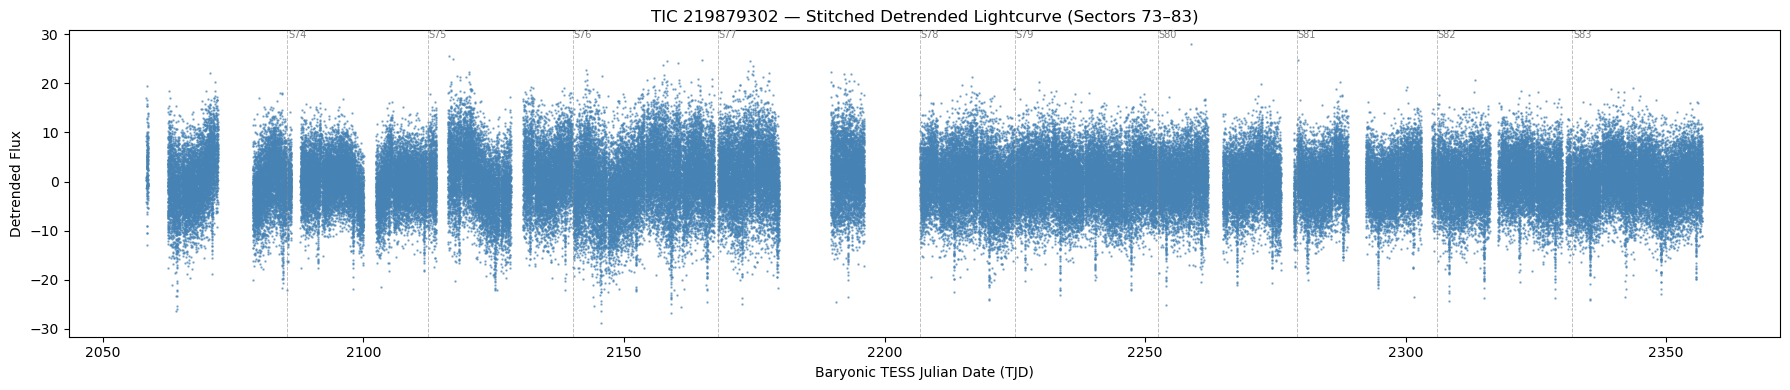

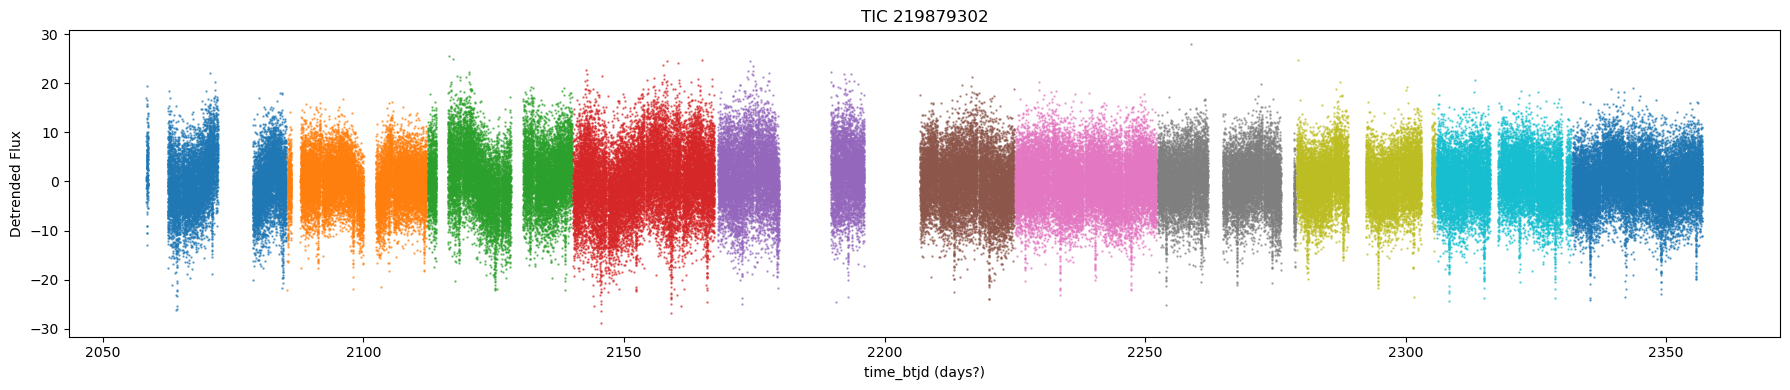

In [2]:
# plotting an individual target at a time to inspect for exoplanet to use in vetting test

%matplotlib inline
import matplotlib.pyplot as plt

target = "219879302"

TARGET_ID = target
LAB_DIR   = os.path.expanduser("~/tess_transit/data/lightcurves/")
SECTORS   = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]

lab_path = os.path.join(LAB_DIR, f"{TARGET_ID}.p")
with open(lab_path, "rb") as f:
    (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
     time_data, cam_data, ccd_data, coeff_ls,
     centroid_xy_data, pos_xy_corr) = pickle.load(f)

# Stitch sectors together
all_time, all_flux = [], []

for sector in SECTORS:
    try:
        flux        = np.array(detrend_data[sector].unmasked)
        time_sector = np.asarray(time_data[sector], dtype=float)
        time_btjd   = cadences_to_btjd(time_sector)
        
        all_time.append(time_btjd)
        all_flux.append(flux)
    except Exception as e:
        print(f"  Sector {sector} skipped: {e}")

all_time = np.concatenate(all_time) #another version of stitching when we are not in lightcurve format
all_flux = np.concatenate(all_flux)

# Sort by time just in case
sort_idx = np.argsort(all_time)
all_time = all_time[sort_idx]
all_flux = all_flux[sort_idx]

# Plot
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(all_time, all_flux, lw=0, marker='.', markersize=1.5, color='steelblue', alpha=0.6)

# Mark and label sector boundaries
for sector in SECTORS[1:]:
    sector_start = cadences_to_btjd(np.asarray(time_data[sector], dtype=float))[0]
    ax.axvline(sector_start, color='gray', lw=0.7, linestyle='--', alpha=0.5)
    ax.text(sector_start + 0.1, ax.get_ylim()[1], f"S{sector}", fontsize=7, color='gray', va='top')


ax.set_xlabel("Baryonic TESS Julian Date (TJD)")
ax.set_ylabel("Detrended Flux")
ax.set_title(f"TIC {TARGET_ID} — Stitched Detrended Lightcurve (Sectors 73–83)")
plt.tight_layout()
plt.show()
plt.close()



#plotting sector by sector

fig, ax = plt.subplots(figsize=(18, 4))
for i, sector in enumerate(SECTORS):
    flux        = np.array(detrend_data[sector].unmasked)
    time_sector = np.asarray(time_data[sector], dtype=float)
    time_btjd   = cadences_to_btjd(time_sector)
    ax.plot(time_btjd, flux, lw=0, marker='.', markersize=1.5, alpha=0.6, label=f"S{sector}")

ax.set_xlabel("time_btjd (days?)")
ax.set_ylabel("Detrended Flux")
ax.set_title(f"TIC {TARGET_ID}")
plt.tight_layout()
plt.show()
plt.close()

# Check Transit Points Plotting

Detected period:  4885 cad (6.785 days)
Detected SNR:     64.65
1.5
1035


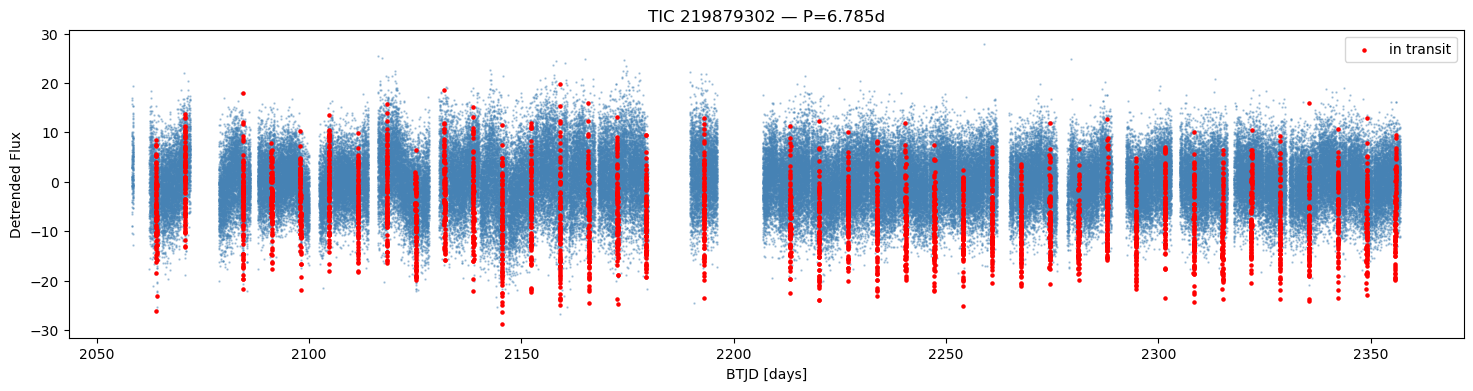

In [3]:

# new plotting method to try and fix the t0 issue


target = "219879302"

SECTORS     = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
RESULTS_DIR = "/home/juliajos/tess_transit/data/high_snr_results/"
LAB_DIR     = os.path.expanduser("~/tess_transit/data/lightcurves/")
first_sector = SECTORS[0]

# Load search results
results_path = os.path.join(RESULTS_DIR, f"{target}_results.p")
with open(results_path, "rb") as f:
    results_real = pickle.load(f)


#best results of the search, "real" in that it is not injected
best_real = results_real['best_candidates'][0] 
print(f"Detected period:  {best_real['period_cadences']} cad ({best_real['period_days']:.3f} days)")
print(f"Detected SNR:     {best_real['snr']:.2f}")

det_period_days   = best_real['period_days']
det_duration_days = cadence_to_days(best_real['duration'])
det_t0_btjd = (best_real['epoch_cadences'] + best_real['duration'] / 2) * (120 / 86400)
print(det_t0_btjd)
print(best_real['epoch_cadences'])


def in_transit_mask(time_bjd, period_days, t0_bjd, duration_days):
    """Boolean mask: True where time falls within a transit window."""
    if period_days <= 0 or duration_days <= 0:
        return np.zeros_like(time_bjd, dtype=bool)
    phase = ((time_bjd - t0_bjd + 0.5 * period_days) % period_days) - 0.5 * period_days
    return np.abs(phase) <= 0.5 * duration_days

# Concatenate all sectors
cad  = np.concatenate([np.asarray(time_data[s]) for s in SECTORS])
flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])

# Convert cadences to BTJD
bjd = cad * (120 / 86400)

# Transit mask in BTJD
P   = det_period_days
t0  = det_t0_btjd  
dur = det_duration_days

phase     = ((bjd - t0 + 0.5*P) % P) - 0.5*P
intransit = np.abs(phase) <= 0.5*dur

# Plot
plt.figure(figsize=(18,4))
plt.scatter(bjd, flux, s=0.5, alpha=0.4, color='steelblue')
plt.scatter(bjd[intransit], flux[intransit], s=5, color='red', label='in transit')
plt.xlabel("BTJD [days]")
plt.ylabel("Detrended Flux")
plt.title(f"TIC {target} — P={P:.3f}d")
plt.legend()
plt.show()

# redoing it but redoing the search with threshold remover thing off

Loading TESS/data/light_curves/160602429.p ...
Available sectors: [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
Using sectors: [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
Data span: 298.6 days, max period set to 149.3 days
Period range: 0.50 - 149.3 days

--- Duration: 30 cadences (1.0 hours) ---
  Sector 73 (fft) ...
  Sector 74 (fft) ...
  Sector 75 (fft) ...
  Sector 76 (fft) ...
  Sector 77 (fft) ...
  Sector 78 (fft) ...
  Sector 79 (fft) ...
  Sector 80 (fft) ...
  Sector 81 (fft) ...
  Sector 82 (fft) ...
  Sector 83 (fft) ...

--- Duration: 60 cadences (2.0 hours) ---
  Sector 73 (fft) ...
  Sector 74 (fft) ...
  Sector 75 (fft) ...
  Sector 76 (fft) ...
  Sector 77 (fft) ...
  Sector 78 (fft) ...
  Sector 79 (fft) ...
  Sector 80 (fft) ...
  Sector 81 (fft) ...
  Sector 82 (fft) ...
  Sector 83 (fft) ...

--- Duration: 90 cadences (3.0 hours) ---
  Sector 73 (fft) ...
  Sector 74 (fft) ...
  Sector 75 (fft) ...
  Sector 76 (fft) ...
  Sector 77 (fft) ...
  Sector 78 (fft) ...


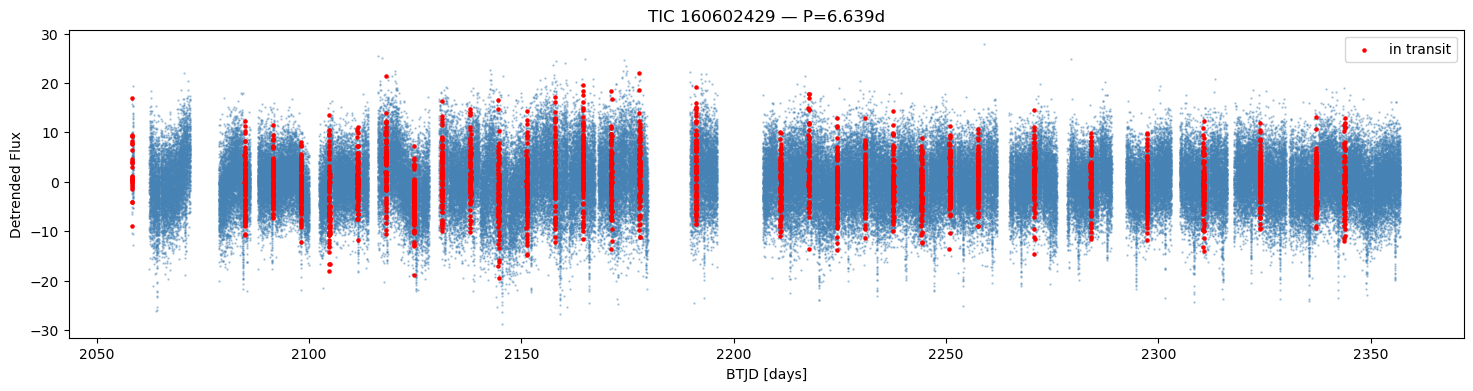

In [4]:
# new plotting method to try and fix the t0 issue


target = "160602429"

SECTORS     = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
RESULTS_DIR = "/nfs/turbo/umor-tjamila/TESS/data/output"
LAB_DIR     = os.path.expanduser("TESS/data/light_curves/")
first_sector = SECTORS[0]

from tess_transit.search import SearchConfig, run_search

results_real = run_search(
    os.path.join(LAB_DIR, f"{target}.p"),
    sectors=SECTORS,
    config=SearchConfig(
        durations=np.array([30, 60, 90, 120]),
        min_period_days=0.5,
        max_period_days=None,
        min_transits=2,
    )
)


#best results of the search, "real" in that it is not injected
best_real = results_real['best_candidates'][0] 
print(f"Detected period:  {best_real['period_cadences']} cad ({best_real['period_days']:.3f} days)")
print(f"Detected SNR:     {best_real['snr']:.2f}")

det_period_days   = best_real['period_days']
det_duration_days = cadence_to_days(best_real['duration'])
det_t0_btjd = (best_real['epoch_cadences'] + best_real['duration'] / 2) * (120 / 86400)
print(det_t0_btjd)
print(best_real['epoch_cadences'])


def in_transit_mask(time_bjd, period_days, t0_bjd, duration_days):
    """Boolean mask: True where time falls within a transit window."""
    if period_days <= 0 or duration_days <= 0:
        return np.zeros_like(time_bjd, dtype=bool)
    phase = ((time_bjd - t0_bjd + 0.5 * period_days) % period_days) - 0.5 * period_days
    return np.abs(phase) <= 0.5 * duration_days

# Concatenate all sectors
cad  = np.concatenate([np.asarray(time_data[s]) for s in SECTORS])
flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])

# Convert cadences to BTJD
bjd = cad * (120 / 86400)

# Transit mask in BTJD
P   = det_period_days
t0  = det_t0_btjd  
dur = det_duration_days

phase     = ((bjd - t0 + 0.5*P) % P) - 0.5*P
intransit = np.abs(phase) <= 0.5*dur

# Plot
plt.figure(figsize=(18,4))
plt.scatter(bjd, flux, s=0.5, alpha=0.4, color='steelblue')
plt.scatter(bjd[intransit], flux[intransit], s=5, color='red', label='in transit')
plt.xlabel("BTJD [days]")
plt.ylabel("Detrended Flux")
plt.title(f"TIC {target} — P={P:.3f}d")
plt.legend()
plt.show()

In [18]:
#diagnostic for the above t0 for the graph:

TARGET_ID   = target
SECTORS     = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
RESULTS_DIR = "/nfs/turbo/umor-tjamila/TESS/data/output"
LAB_DIR     = os.path.expanduser("TESS/data/light_curves/")
first_sector = SECTORS[0]

# Load search results
results_path = os.path.join(RESULTS_DIR, f"{TARGET_ID}_results.p")
with open(results_path, "rb") as f:
    results_real = pickle.load(f)

print(results_real['best_candidates'][0])

{'duration': 90, 'period_cadences': 4780, 'epoch_cadences': 2575, 'snr': 43.09628836169963, 'period_days': 6.638888888888889, 'duration_hours': 3.0}


# Running the full vettng on the same target visualized above and results (non plotting for now but sector p values returned)

In [5]:
# running vetting test (non injection) on inspected targets from above - sigma filtering applied to remove large systematic outlier points

%matplotlib inline
import pickle
import numpy as np
import os

target = "441717731"

TARGET_ID   = target
SECTORS     = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
RESULTS_DIR = "/home/juliajos/tess_transit/data/high_snr_results/"
LAB_DIR     = os.path.expanduser("~/tess_transit/data/lightcurves/")
first_sector = SECTORS[0]

# Load search results
results_path = os.path.join(RESULTS_DIR, f"{TARGET_ID}_results.p")
with open(results_path, "rb") as f:
    results_real = pickle.load(f)


#best results of the search, "real" in that it is not injected
best_real = results_real['best_candidates'][0]
print(f"Detected period:  {best_real['period_cadences']} cad ({best_real['period_days']:.3f} days)")
print(f"Detected SNR:     {best_real['snr']:.2f}")

det_period_days   = best_real['period_days']
det_duration_days = cadence_to_days(best_real['duration'])
det_t0_btjd       = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])

# Load lab pickle
lab_path = os.path.join(LAB_DIR, f"{TARGET_ID}.p")
with open(lab_path, "rb") as f:
    (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
     time_data, cam_data, ccd_data, coeff_ls,
     centroid_xy_data, pos_xy_corr) = pickle.load(f)

# Vetting tests sector by sector
sector_cm_pvals  = []
sector_eop_pvals = []

for sector in SECTORS:
    try:
        lc_sector   = np.array(detrend_data[sector].unmasked)
        time_sector = np.asarray(time_data[sector], dtype=float)
        time_btjd_s = cadences_to_btjd(time_sector)

        pos_xy_sector = pos_xy_corr[sector]
        mom_xy        = centroid_xy_data[sector]
        pos_cor1 = np.array(pos_xy_sector[0].unmasked)
        pos_cor2 = np.array(pos_xy_sector[1].unmasked)
        mom1     = np.array(mom_xy[0].unmasked)
        mom2     = np.array(mom_xy[1].unmasked)
    except Exception as e:
        print(f"  Sector {sector} skipped: {e}")
        continue
        
    ################################## Sector quality flag ######################
    centroid_x = mom1 - pos_cor1
    centroid_y = mom2 - pos_cor2
        
    cx_range = np.nanmax(centroid_x) - np.nanmin(centroid_x)
    cy_range = np.nanmax(centroid_y) - np.nanmin(centroid_y)
    cx_std   = np.nanstd(centroid_x)
    cy_std   = np.nanstd(centroid_y)
        
        # if peak-to-peak drift is more than 10x the typical scatter, flag it
    if cx_range > 10 * cx_std or cy_range > 10 * cy_std:
        print(f" Sector {sector}: centroid drift detected, excluding from combination")
        sector_cm_pvals.append(np.nan)  # nan gets ignored by fishers_method
        sector_eop_pvals.append(np.nan)
        continue
            
    try:
        ######################## Pre-filter outlier cadences before CM test #############################
        med = np.median(lc_sector)
        std = np.std(lc_sector)
        bad = np.abs(lc_sector - med) > 15 * std
        if np.sum(bad) > 0:
            print(f"  Sector {sector}: clipping {np.sum(bad)} outlier cadences")
            lc_sector = lc_sector.copy()
            lc_sector[bad] = med #replaces bad points with the median value because the tests rely on the same shape arrays so we can't just remove them

        cm_p = calculate_enhanced_centroid_motion_pvalue(
            lc_sector, time_btjd=time_btjd_s,
            mom1=mom1, mom2=mom2, pos1=pos_cor1, pos2=pos_cor2,
            period_days=det_period_days, t0_btjd=det_t0_btjd,
            duration_days=max(det_duration_days, cadence_to_days(6)),
            baseline_factor=3.0, sector=sector, plot= False
        )
        plt.show()
        plt.close('all')
    except Exception as e:
        print(f"  CM test failed: {e}")
        cm_p = np.nan
    sector_cm_pvals.append(cm_p)
    print(f"  CM p-value:  {cm_p:.4g}" if not np.isnan(cm_p) else "  CM: NaN")

    try:
        bin_size    = 0.005
        bins        = np.arange(np.min(time_btjd_s), np.max(time_btjd_s) + bin_size, bin_size)
        bin_indices = np.digitize(time_btjd_s, bins)
        b_time, b_flux = [], []
        for i in range(1, len(bins)):
            mask = bin_indices == i
            if np.any(mask):
                b_time.append(np.mean(time_btjd_s[mask]))
                b_flux.append(np.mean(lc_sector[mask]))
        b_time = np.array(b_time)
        b_flux = np.array(b_flux)

        eop = even_odd_phase_our_data(
            b_flux, time_btjd=b_time,
            period_days=det_period_days, t0_btjd=det_t0_btjd,
            duration_days=det_duration_days,
            plot_size=0.15, same_axes=False, plot= False
        )
    except Exception as e:
        print(f"  Even-odd test failed: {e}")
        eop = np.nan
    sector_eop_pvals.append(eop)
    print(f"  EOP p-value: {eop:.4g}" if not np.isnan(eop) else "  EOP: NaN")

# Combined results
ccombined_cm_p  = stouffers_method(sector_cm_pvals)
combined_eop_p = stouffers_method(sector_eop_pvals)

score = (
    combined_score_weighted(combined_cm_p, combined_eop_p)
    if np.isfinite(combined_cm_p) or np.isfinite(combined_eop_p)
    else np.nan
)

print("\n" + "=" * 60)
print(f"VETTING RESULT — TIC {TARGET_ID}")
print("=" * 60)
print(f"  Detected period:  {det_period_days:.4f} d")
print(f"  Detected SNR:     {best_real['snr']:.2f}")
print(f"  CM combined p:    {combined_cm_p:.4g}")
print(f"  EvenOdd comb. p:  {combined_eop_p:.4g}")
print(f"  Weighted score:   {score:.4g}")

# Thresholds
CM_FAIL_ALPHA     = 0.01
EOP_FAIL_ALPHA    = 0.01
SCORE_FAIL_ALPHA  = 0.05
SCORE_WARN_ALPHA  = 0.02

cm_fail = np.isfinite(combined_cm_p) and combined_cm_p < CM_FAIL_ALPHA
eop_fail = np.isfinite(combined_eop_p) and combined_eop_p < EOP_FAIL_ALPHA

print()
print("  Individual diagnostic flags:")
print(f"    Centroid motion: {'FAIL' if cm_fail else 'PASS'}")
print(f"    Even/Odd:        {'FAIL' if eop_fail else 'PASS'}")

print()
if np.isnan(score):
    print("  Result: could not compute score.")

elif cm_fail:
    print("  Result: FAILS vetting — significant centroid motion detected. ✗")

elif eop_fail:
    print("  Result: FAILS vetting — significant odd/even depth difference detected. ✗")

elif score < SCORE_FAIL_ALPHA:
    print("  Result: FAILS vetting — weighted score indicates significant false-positive behavior. ✗")

elif score < SCORE_WARN_ALPHA:
    print("  Result: AMBIGUOUS — weighted score is low; worth manual inspection.")

else:
    print("  Result: PASSES vetting — no strong evidence from these diagnostics.")

Detected period:  5415 cad (7.521 days)
Detected SNR:     122.29
  CM p-value:  0.2588
  EOP p-value: 0.08047
  CM p-value:  0.001437
  EOP p-value: 2.244e-11
  CM p-value:  0.13
  EOP p-value: 2.59e-10
  CM p-value:  0.8697
  EOP p-value: 0.05108
  CM p-value:  0.8833
  EOP p-value: 8.818e-06
  CM p-value:  0.4663
  EOP p-value: 0.9914
  CM p-value:  0.2563
  EOP p-value: 0.6277
  CM p-value:  0.7561
  EOP p-value: 0.3607
  CM p-value:  0.9277
  EOP p-value: 8.057e-06
  CM p-value:  0.09176
  EOP p-value: 0.0004578
  CM p-value:  0.2149
  EOP p-value: 0.5231

VETTING RESULT — TIC 441717731
  Detected period:  7.5208 d
  Detected SNR:     122.29
  CM combined p:    3.099e-05
  EvenOdd comb. p:  1.801e-14
  Weighted score:   2.324e-05

  Individual diagnostic flags:
    Centroid motion: FAIL
    Even/Odd:        FAIL

  Result: FAILS vetting — significant centroid motion detected. ✗


In [6]:
# Plot stitched lightcurve with predicted transit markers
cad  = np.concatenate([np.asarray(time_data[s]) for s in SECTORS])
flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])
bjd  = cadences_to_btjd(cad)

sort_idx = np.argsort(bjd)
bjd  = bjd[sort_idx]
flux = flux[sort_idx]

# predicted transit times
n_min = int(np.floor((bjd.min() - det_t0_btjd) / det_period_days))
n_max = int(np.ceil((bjd.max()  - det_t0_btjd) / det_period_days))
transit_times = [det_t0_btjd + n * det_period_days for n in range(n_min, n_max + 1)
                 if bjd.min() <= det_t0_btjd + n * det_period_days <= bjd.max()]

fig, ax = plt.subplots(figsize=(18, 4))
ax.scatter(bjd, flux, s=0.5, alpha=0.8, color='steelblue')
for tt in transit_times:
    ax.axvline(tt, color='red', lw=0.8, alpha=0.3)
ax.set_xlabel("BTJD [days]")
ax.set_ylabel("Detrended Flux")
ax.set_title(f"TIC {TARGET_ID} — P={det_period_days:.3f}d, predicted transits marked")
plt.tight_layout()
plt.show()

# List of high SNR targets from the search (SNR >7) saved to tess_transit/data/high_snr_targets

In [24]:
# high snr targets from results of the search only

#printing high SNR targets 
import os
import pickle

RESULTS_DIR = "/nfs/turbo/umor-tjamila/TESS/data/output"

high_snr_targets = []

for fname in os.listdir(RESULTS_DIR):
    target_id = fname.replace("_results.p", "")
    if not target_id.isdigit():
        continue

    fpath = os.path.join(RESULTS_DIR, fname)
    try:
        with open(fpath, "rb") as f:
            results = pickle.load(f)

        best = results['best_candidates'][0]
        snr  = best['snr']

        if snr > 7:
            high_snr_targets.append({
                'target_id':      target_id,
                'snr':            snr,
                'period_days':    best['period_days'],
                'period_cadences': best['period_cadences'],
            })

    except Exception as e:
        print(f"  Could not load {fname}: {e}")

high_snr_targets.sort(key=lambda x: x['snr'], reverse=True)

print(f"Targets with SNR > 7: {len(high_snr_targets)}")
print("=" * 55)
print(f"{'Target ID':<20} {'SNR':>8} {'Period (days)':>15}")
print("-" * 55)
for t in high_snr_targets:
    print(f"{t['target_id']:<20} {t['snr']:>8.2f} {t['period_days']:>15.4f}")
    
SAVE_DIR = "tess_transit/data/high_snr_targets"
os.makedirs(SAVE_DIR, exist_ok=True)

target_ids = [t['target_id'] for t in high_snr_targets]

print(f"Saved {len(target_ids)} target IDs to {SAVE_DIR}/target_ids.txt")

FileNotFoundError: [Errno 2] No such file or directory: '/nfs/turbo/umor-tjamila/TESS/data/output'

# Full vetting run with all of the targets and results saved to respective files in tess_transit (saved under fourth_run)

In [ ]:
# full vetting run with all high SNR targets, saving the results to tess_trasnit/data/results and images

#imports
import gc
import pickle
import numpy as np
import os
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for saving
import matplotlib.pyplot as plt

#where to save results and where we import the light curvese from
RESULTS_DIR = "/home/juliajos/tess_transit/data/high_snr_results/"
LAB_DIR     = os.path.expanduser("~/tess_transit/data/lightcurves/")
SECTORS     = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
first_sector = SECTORS[0]


OUT_RESULTS = "/home/juliajos/tess_transit/data/fourth_run_results"
OUT_IMAGES  = "/home/juliajos/tess_transit/data/fourth_run_images"
os.makedirs(OUT_RESULTS, exist_ok=True)
os.makedirs(OUT_IMAGES,  exist_ok=True)

#loading in high snr targets
target_ids = [f.replace("_results.p", "") for f in os.listdir(RESULTS_DIR) if f.endswith("_results.p")]

# rebuild high_snr_targets list with period/snr info from results pickles
high_snr_targets = []
for tid in target_ids: #tic ids is tid so for id in tess id list
    fpath = os.path.join(RESULTS_DIR, f"{tid}_results.p")
    with open(fpath, "rb") as f:
        results = pickle.load(f)
    best = results['best_candidates'][0]
    high_snr_targets.append({
        'target_id':       tid,
        'snr':             best['snr'],
        'period_days':     best['period_days'],
        'period_cadences': best['period_cadences'],
    }) 

#for TIC ID in high SNR targets
for target in high_snr_targets:
    TARGET_ID = target['target_id']
    print(f"\n{'='*60}")
    print(f"Processing TIC {TARGET_ID}  (SNR={target['snr']:.2f})")
    print(f"{'='*60}")

    # load search results
    results_path = os.path.join(RESULTS_DIR, f"{TARGET_ID}_results.p")
    try:
        with open(results_path, "rb") as f:
            results_real = pickle.load(f)
    except Exception as e:
        print(f"  Could not load results: {e}, skipping.")
        continue

    best_real         = results_real['best_candidates'][0] #best results from the search bc the search gives SNR for every combination
    det_period_days   = best_real['period_days']
    det_duration_days = cadence_to_days(best_real['duration'])
    det_t0_btjd       = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])

    # load lab pickle
    lab_path = os.path.join(LAB_DIR, f"{TARGET_ID}.p") #lightcurve data
    try:
        with open(lab_path, "rb") as f:
            (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
             time_data, cam_data, ccd_data, coeff_ls,
             centroid_xy_data, pos_xy_corr) = pickle.load(f)
            
    except Exception as e:
        print(f"  Could not load lab pickle: {e}, skipping.")
        continue     

    # vetting loop
    sector_cm_pvals  = []
    sector_eop_pvals = []
    all_time = []
    all_flux = []

    for sector in SECTORS: #running vetting sector by sector
        try:
            lc_sector   = np.array(detrend_data[sector].unmasked) #extracting data out
            time_sector = np.asarray(time_data[sector], dtype=float)
            time_btjd_s = cadences_to_btjd(time_sector)

            pos_xy_sector = pos_xy_corr[sector]
            mom_xy        = centroid_xy_data[sector]
            pos_cor1 = np.array(pos_xy_sector[0].unmasked)
            pos_cor2 = np.array(pos_xy_sector[1].unmasked)
            mom1     = np.array(mom_xy[0].unmasked)
            mom2     = np.array(mom_xy[1].unmasked)
        except Exception as e:
            print(f"  Sector {sector} skipped: {e}")
            continue

        # centroid drift quality flag - basically we add this because we kepy getting single point weird anomolies in our result lightcurves
        centroid_x = mom1 - pos_cor1
        centroid_y = mom2 - pos_cor2
        cx_range = np.nanmax(centroid_x) - np.nanmin(centroid_x)
        cy_range = np.nanmax(centroid_y) - np.nanmin(centroid_y)
        cx_std   = np.nanstd(centroid_x)
        cy_std   = np.nanstd(centroid_y)
        if cx_range > 10 * cx_std or cy_range > 10 * cy_std:
            print(f" Sector {sector}: centroid drift detected, excluding.")
            sector_cm_pvals.append(np.nan)
            sector_eop_pvals.append(np.nan)
            continue

        try:
            ## sigma cliping to prevent the single sector outliers, if the lightcurves look weird, etc. -> double check if 5 is too little ***
            med = np.median(lc_sector)
            std = np.std(lc_sector)
            bad = np.abs(lc_sector - med) > 15 * std
            if np.sum(bad) > 0:
                print(f"  Sector {sector}: clipping {np.sum(bad)} outlier cadences")
                lc_sector = lc_sector.copy()
                lc_sector[bad] = med
                for arr in [mom1, mom2, pos_cor1, pos_cor2]:
                    arr[bad] = np.median(arr) #replaces the bad points with the median because the test relies on specific numbers of points in the array

            cm_p = calculate_enhanced_centroid_motion_pvalue(
                lc_sector, time_btjd=time_btjd_s,
                mom1=mom1, mom2=mom2, pos1=pos_cor1, pos2=pos_cor2,
                period_days=det_period_days, t0_btjd=det_t0_btjd,
                duration_days=max(det_duration_days, cadence_to_days(6)),
                baseline_factor=3.0, sector=sector, plot=False  ###################################### if plot ######################################
            )
        except Exception as e:
            print(f"  CM test failed: {e}")
            cm_p = np.nan
        sector_cm_pvals.append(cm_p)
        print(f"  Sector {sector} CM p:  {cm_p:.4g}" if not np.isnan(cm_p) else f"  Sector {sector} CM: NaN")

        try:
            bin_size    = 0.005 #we bin to prevent noise from too many points when performing the test
            bins        = np.arange(np.min(time_btjd_s), np.max(time_btjd_s) + bin_size, bin_size)
            bin_indices = np.digitize(time_btjd_s, bins)
            b_time, b_flux = [], []
            for i in range(1, len(bins)):
                mask = bin_indices == i
                if np.any(mask):
                    b_time.append(np.mean(time_btjd_s[mask]))
                    b_flux.append(np.mean(lc_sector[mask]))
            b_time = np.array(b_time)
            b_flux = np.array(b_flux)

            eop = even_odd_phase_our_data(
                b_flux, time_btjd=b_time,
                period_days=det_period_days, t0_btjd=det_t0_btjd,
                duration_days=det_duration_days,
                plot_size=0.15, same_axes=False, plot=False
            )
        except Exception as e:
            print(f"  EOP test failed: {e}")
            eop = np.nan
        sector_eop_pvals.append(eop)
        print(f"  Sector {sector} EOP p: {eop:.4g}" if not np.isnan(eop) else f"  Sector {sector} EOP: NaN")

        all_time.append(time_btjd_s)
        all_flux.append(lc_sector)

    # combined results
    combined_cm_p  = stouffers_method(sector_cm_pvals)
    combined_eop_p = stouffers_method(sector_eop_pvals)
    score = (
        combined_score_weighted(combined_cm_p, combined_eop_p)
        if np.isfinite(combined_cm_p) or np.isfinite(combined_eop_p)
        else np.nan
    )

    # thresholds
    CM_FAIL_ALPHA    = 0.01
    EOP_FAIL_ALPHA   = 0.01
    SCORE_FAIL_ALPHA = 0.05
    SCORE_WARN_ALPHA = 0.02

    cm_fail  = np.isfinite(combined_cm_p)  and combined_cm_p  < CM_FAIL_ALPHA
    eop_fail = np.isfinite(combined_eop_p) and combined_eop_p < EOP_FAIL_ALPHA

    if np.isnan(score):
        verdict = "INSUFFICIENT DATA"
    elif cm_fail:
        verdict = "FAILS — significant centroid motion detected"
    elif eop_fail:
        verdict = "FAILS — significant odd/even depth difference detected"
    elif score < SCORE_FAIL_ALPHA:
        verdict = "FAILS — weighted score indicates false-positive behavior"
    elif score < SCORE_WARN_ALPHA:
        verdict = "AMBIGUOUS — worth manual inspection"
    else:
        verdict = "PASSES — no strong evidence from these diagnostics"

    print(f"\n  CM combined p:   {combined_cm_p:.4g}")
    print(f"  EOP combined p:  {combined_eop_p:.4g}")
    print(f"  Weighted score:  {score:.4g}")
    print(f"  CM flag:         {'FAIL' if cm_fail else 'PASS'}")
    print(f"  EOP flag:        {'FAIL' if eop_fail else 'PASS'}")
    print(f"  Verdict:         {verdict}")

    # save results pickle
    result_out = {
        'target_id':       TARGET_ID,
        'snr':             best_real['snr'],
        'period_days':     det_period_days,
        'duration_days':   det_duration_days,
        'combined_cm_p':   combined_cm_p,
        'combined_eop_p':  combined_eop_p,
        'score':           score,
        'verdict':         verdict,
        'sector_cm_pvals': sector_cm_pvals,
        'sector_eop_pvals': sector_eop_pvals,
    }
    with open(os.path.join(OUT_RESULTS, f"{TARGET_ID}_vetting.p"), "wb") as f:
        pickle.dump(result_out, f)

    # save stitched light curve image
    if all_time:
        all_time_cat = np.concatenate(all_time) #all time stitched (concatentated bc its not in lightcurve format so we cant .stitch)
        all_flux_cat = np.concatenate(all_flux)
        sort_idx = np.argsort(all_time_cat)

        t_start, t_end = all_time_cat.min(), all_time_cat.max()
        n_min = int(np.floor((t_start - det_t0_btjd) / det_period_days))
        n_max = int(np.ceil((t_end   - det_t0_btjd) / det_period_days))
        transit_times = [det_t0_btjd + n * det_period_days for n in range(n_min, n_max + 1)
                         if t_start <= det_t0_btjd + n * det_period_days <= t_end]

        fig, ax = plt.subplots(figsize=(16, 4))
        ax.plot(all_time_cat[sort_idx], all_flux_cat[sort_idx], '.', ms=1, color='navy', alpha=0.6)
        for tt in transit_times:
            ax.axvline(tt, color='red', alpha=0.4, linewidth=0.5, linestyle='--') ################# plotting the transit times here from search params
        ax.set_xlabel('BTJD')
        ax.set_ylabel('Normalized flux')
        ax.set_title(f'TIC {TARGET_ID} — SNR={best_real["snr"]:.1f}  score={score:.3g}  {verdict}')
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_IMAGES, f"{TARGET_ID}_lightcurve.png"), dpi=150)
        plt.close(fig)

    # clean up otherwise the kernel will die after each target
    del lc_data, processed_lc_data, detrend_data, norm_offset, quality_data
    del time_data, cam_data, ccd_data, coeff_ls, centroid_xy_data, pos_xy_corr
    del results_real
    gc.collect()

print(f"\nDone. Results in {OUT_RESULTS}, images in {OUT_IMAGES}")


# load all results and summarize
all_results = []
for fname in os.listdir(OUT_RESULTS):
    if fname.endswith("_vetting.p"):
        with open(os.path.join(OUT_RESULTS, fname), "rb") as f:
            all_results.append(pickle.load(f))

passes    = sum(1 for r in all_results if "PASSES" in r['verdict'])
fails     = sum(1 for r in all_results if "FAILS" in r['verdict'])
ambiguous = sum(1 for r in all_results if "AMBIGUOUS" in r['verdict'])
insuff    = sum(1 for r in all_results if "INSUFFICIENT" in r['verdict'])

print(f"\nSUMMARY — {len(all_results)} targets vetted")
print(f"  PASSES:      {passes}")
print(f"  FAILS:       {fails}")
print(f"  AMBIGUOUS:   {ambiguous}")
print(f"  INSUFFICIENT:{insuff}")



Processing TIC 1400774494  (SNR=7.80)
  Sector 73 CM p:  0.001027
  Sector 73 EOP p: 0.4048
  Sector 74 CM p:  0.0361
  Sector 74 EOP p: 0.9597
  Sector 75 CM p:  2.017e-13
  Sector 75 EOP p: 0.5489
  Sector 76 CM p:  0.1942
  Sector 76 EOP p: 0.3779
  Sector 77 CM p:  0.02801
  Sector 77 EOP p: 0.2014
  Sector 78 CM p:  0.002634
  Sector 78 EOP p: 0.5959
  Sector 79 CM p:  0.2419
  Sector 79 EOP p: 0.276
  Sector 80 CM p:  0.0003368
  Sector 80 EOP p: 0.2754
  Sector 81 CM p:  0.04101
  Sector 81 EOP p: 0.4157
  Sector 82 CM p:  0.007295
  Sector 82 EOP p: 0.3199
  Sector 83 CM p:  1.191e-06
  Sector 83 EOP p: 0.4933

  CM combined p:   1.277e-19
  EOP combined p:  0.3627
  Weighted score:  0.09067
  CM flag:         FAIL
  EOP flag:        PASS
  Verdict:         FAILS — significant centroid motion detected

Processing TIC 232604432  (SNR=7.28)
  Sector 73 CM p:  3.024e-22
  Sector 73 EOP p: 0.7202
  Sector 74 CM p:  0.1527
  Sector 74 EOP p: 0.4956
 Sector 75: centroid drift detect

/tmp/ipykernel_265237/2897981693.py:99: RuntimeWarning: All-NaN slice encountered
  cx_range = np.nanmax(centroid_x) - np.nanmin(centroid_x)
/tmp/ipykernel_265237/2897981693.py:100: RuntimeWarning: All-NaN slice encountered
  cy_range = np.nanmax(centroid_y) - np.nanmin(centroid_y)
/usr/lib/python3/dist-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Sector 82 EOP p: 0.5826
  Sector 83 CM: NaN
  Sector 83 EOP p: 0.6094

  CM combined p:   4.095e-30
  EOP combined p:  0.09066
  Weighted score:  0.02266
  CM flag:         FAIL
  EOP flag:        PASS
  Verdict:         FAILS — significant centroid motion detected

Processing TIC 229911143  (SNR=169.93)
  Sector 73 CM p:  1.782e-05
  Sector 73 EOP p: 9.343e-35
  Sector 74 CM p:  5.635e-11
  Sector 74 EOP p: 0.000747
  Sector 75 CM p:  0.01661
  Sector 75 EOP p: 3.38e-05
  Sector 76 CM p:  1.481e-19
  Sector 76 EOP p: 0.823
  Sector 77 CM p:  1.67e-08
  Sector 77 EOP p: 0.09728
  Sector 78: clipping 1 outlier cadences
  Sector 78 CM p:  1.098e-15
  Sector 78 EOP p: 0.01258
  Sector 79 CM p:  0.01532
  Sector 79 EOP p: 0.4787
  Sector 80 CM p:  0.2501
  Sector 80 EOP p: 0.2084
  Sector 81 CM p:  0.05413
  Sector 81 EOP p: 0.7071
 Sector 82: centroid drift detected, excluding.
  Sector 83 CM p:  4.365e-08
  Sector 83 EOP p: 0.7102

  CM combined p:   3.832e-38
  EOP combined p:  2.489e

In [8]:
import shutil

PASSED_DIR = "/home/juliajos/tess_transit/data/passed_images"
os.makedirs(PASSED_DIR, exist_ok=True)

for r in all_results:
    if "PASSES" in r['verdict']:
        src = os.path.join(OUT_IMAGES, f"{r['target_id']}_lightcurve.png")
        dst = os.path.join(PASSED_DIR, f"{r['target_id']}_lightcurve.png")
        if os.path.exists(src):
            shutil.copy(src, dst)

print(f"Copied {passes} passing target images to {PASSED_DIR}")

Copied 160 passing target images to /home/juliajos/tess_transit/data/passed_images


# individual phase folding graph

In [ ]:
# new phase 

def plot_phase_fold_basic(target, time_btjd, flux, period_days, t0_btjd, duration_days=None, xlim=0.1, bin_size=0.003):
    """
    Basic phase fold. t0_btjd should be the transit MIDPOINT in BTJD.
    If you have a start-time epoch, pass: t0_btjd = epoch_to_btjd(epoch_cadences, duration_cadences)
    """
    # Fold: phase = 0 at transit center, range [-0.5, 0.5]
    phase = ((time_btjd - t0_btjd + 0.5 * period_days) % period_days) - 0.5 * period_days
    phase_norm = phase / period_days  # normalize so units are in fractions of period

    # Bin
    bins = np.arange(-xlim, xlim + bin_size, bin_size)
    b_phase, b_flux = [], []
    for i in range(1, len(bins)):
        mask = (phase_norm >= bins[i-1]) & (phase_norm < bins[i])
        if np.any(mask):
            b_phase.append(0.5 * (bins[i-1] + bins[i]))
            b_flux.append(np.nanmedian(flux[mask]))
    b_phase = np.array(b_phase)
    b_flux  = np.array(b_flux)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(phase_norm, flux, s=1, color='gray', alpha=0.2, label='data')
    ax.plot(b_phase, b_flux, 'D-', ms=4, color='steelblue', label='binned median')
    ax.axvline(0, color='red', lw=0.8, linestyle='--', label='transit center')
    if duration_days is not None:
        half_dur = (duration_days / period_days) / 2
        ax.axvline(-half_dur, color='red', lw=0.5, linestyle=':')
        ax.axvline( half_dur, color='red', lw=0.5, linestyle=':')
    ax.set_xlim(-xlim, xlim)
    ax.set_xlabel('Phase (fraction of period)')
    ax.set_ylabel('Flux')
    ax.set_title(f'target {target} — Phase fold — P={period_days:.4f} d')
    ax.legend()
    plt.tight_layout()
    plt.show()

Period:   2.4583 d
Duration: 4.00 hr
SNR:      172.26


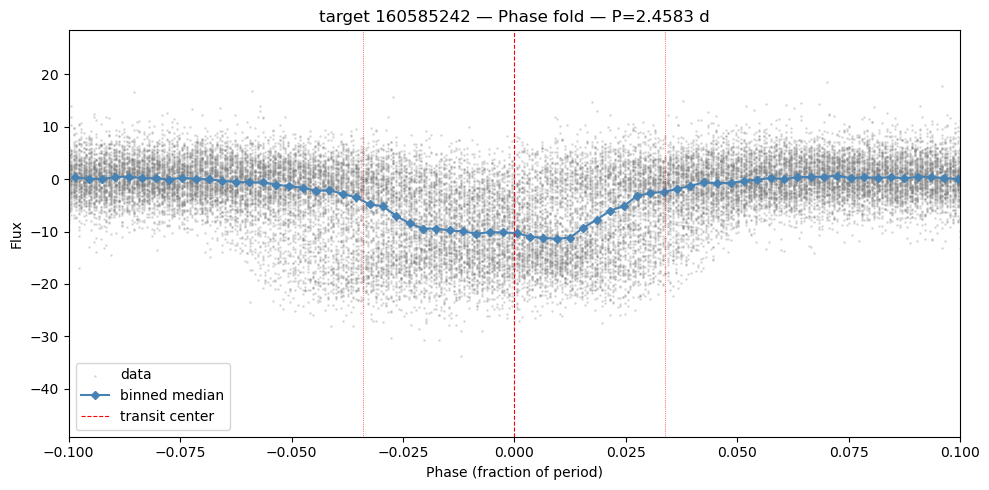

In [ ]:
# Phase fold a single target
target = "160585242"

SECTORS     = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
RESULTS_DIR = "/home/juliajos/tess_transit/data/high_snr_results/"
LAB_DIR     = os.path.expanduser("~/tess_transit/data/lightcurves/")

# Load search results
results_path = os.path.join(RESULTS_DIR, f"{target}_results.p")
with open(results_path, "rb") as f:
    results_real = pickle.load(f)

best_real         = results_real['best_candidates'][0]
det_period_days   = best_real['period_days']
det_duration_days = cadence_to_days(best_real['duration'])
det_t0_btjd       = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])

# Load light curve
lab_path = os.path.join(LAB_DIR, f"{target}.p")
with open(lab_path, "rb") as f:
    (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
     time_data, cam_data, ccd_data, coeff_ls,
     centroid_xy_data, pos_xy_corr) = pickle.load(f)

# Stitch sectors
bjd  = np.concatenate([cadences_to_btjd(np.asarray(time_data[s], dtype=float)) for s in SECTORS])
flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])

# Sort
sort_idx = np.argsort(bjd)
bjd  = bjd[sort_idx]
flux = flux[sort_idx]

print(f"Period:   {det_period_days:.4f} d")
print(f"Duration: {det_duration_days*24:.2f} hr")
print(f"SNR:      {best_real['snr']:.2f}")

plot_phase_fold_basic(target, bjd, flux, det_period_days, det_t0_btjd, det_duration_days)

# Phase folding on all high SNR targets

In [5]:

#script to phase fold all targets and save the images
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for saving

RESULTS_DIR = "/home/juliajos/tess_transit/data/high_snr_results/"
LAB_DIR     = os.path.expanduser("~/tess_transit/data/lightcurves/")
SECTORS     = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
OUT_DIR      = "/home/juliajos/tess_transit/data/high_snr_phase_folds"
os.makedirs(OUT_DIR, exist_ok=True)

#new function to save images instead of show them
def plot_phase_fold_basic(target, time_btjd, flux, period_days, t0_btjd, duration_days=None, xlim=0.1, bin_size=0.003, save_path=None):
    phase = ((time_btjd - t0_btjd + 0.5 * period_days) % period_days) - 0.5 * period_days
    phase_norm = phase / period_days

    bins = np.arange(-xlim, xlim + bin_size, bin_size)
    b_phase, b_flux = [], []
    for i in range(1, len(bins)):
        mask = (phase_norm >= bins[i-1]) & (phase_norm < bins[i])
        if np.any(mask):
            b_phase.append(0.5 * (bins[i-1] + bins[i]))
            b_flux.append(np.nanmedian(flux[mask]))
    b_phase = np.array(b_phase)
    b_flux  = np.array(b_flux)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(phase_norm, flux, s=1, color='gray', alpha=0.2, label='data')
    ax.plot(b_phase, b_flux, 'D-', ms=4, color='steelblue', label='binned median')
    ax.axvline(0, color='red', lw=0.8, linestyle='--', label='transit center')
    if duration_days is not None:
        half_dur = (duration_days / period_days) / 2
        ax.axvline(-half_dur, color='red', lw=0.5, linestyle=':')
        ax.axvline( half_dur, color='red', lw=0.5, linestyle=':')
    ax.set_xlim(-xlim, xlim)
    ax.set_xlabel('Phase (fraction of period)')
    ax.set_ylabel('Flux')
    ax.set_title(f'target {target} — Phase fold — P={period_days:.4f} d')
    ax.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.close(fig)


#get targets to loop through
target_ids = [f.replace("_results.p", "") for f in os.listdir(RESULTS_DIR) if f.endswith("_results.p")]
print(f"Found {len(target_ids)} targets to phase fold")

for target in target_ids:
    results_path = os.path.join(RESULTS_DIR, f"{target}_results.p")
    with open(results_path, "rb") as f:
        results_real = pickle.load(f)

    best_real         = results_real['best_candidates'][0]
    det_period_days   = best_real['period_days']
    det_duration_days = cadence_to_days(best_real['duration'])
    det_t0_btjd       = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])

    lab_path = os.path.join(LAB_DIR, f"{target}.p")
    with open(lab_path, "rb") as f:
        (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
         time_data, cam_data, ccd_data, coeff_ls,
         centroid_xy_data, pos_xy_corr) = pickle.load(f)
        
    bjd  = np.concatenate([cadences_to_btjd(np.asarray(time_data[s], dtype=float)) for s in SECTORS])
    flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])

    sort_idx = np.argsort(bjd)
    bjd  = bjd[sort_idx]
    flux = flux[sort_idx]

    save_path = os.path.join(OUT_DIR, f"{target}_phase_fold.png")
    plot_phase_fold_basic(target, bjd, flux, det_period_days, det_t0_btjd, det_duration_days, save_path=save_path)
    print(f"{target}: Phase fold saved")


    del results_real, lc_data, processed_lc_data, detrend_data, norm_offset, quality_data
    del time_data, cam_data, ccd_data, coeff_ls, centroid_xy_data, pos_xy_corr
    gc.collect()

print(f"\nAll phase folds saved to {OUT_DIR}")

Found 678 targets to phase fold
1400774494: Phase fold saved
232604432: Phase fold saved
353734834: Phase fold saved
362256656: Phase fold saved
362256498: Phase fold saved
357044866: Phase fold saved
199682618: Phase fold saved
229452938: Phase fold saved
1717573224: Phase fold saved
1400821476: Phase fold saved
359629653: Phase fold saved
229451506: Phase fold saved
359677968: Phase fold saved
441765495: Phase fold saved
230136419: Phase fold saved
459982699: Phase fold saved
1400889668: Phase fold saved
165551380: Phase fold saved
232982511: Phase fold saved
229965220: Phase fold saved
1201363683: Phase fold saved
160551435: Phase fold saved
258701096: Phase fold saved
198416967: Phase fold saved
229910184: Phase fold saved
229671592: Phase fold saved
1717811870: Phase fold saved
219794517: Phase fold saved
1400813581: Phase fold saved
441725501: Phase fold saved
230090072: Phase fold saved
199607786: Phase fold saved
230080910: Phase fold saved
356896555: Phase fold saved
199665772

# running phase folding on only passed vetting targets

In [ ]:

#running phase folding only on the targets that passed vetting

RESULTS_DIR  = "/home/juliajos/tess_transit/data/high_snr_results/"
VETTING_DIR  = "/home/juliajos/tess_transit/data/fourth_run_results"
LAB_DIR      = os.path.expanduser("~/tess_transit/data/lightcurves/")
SECTORS      = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]

OUT_DIR = "/home/juliajos/tess_transit/data/high_snr_phase_fold_passed_vetting"
os.makedirs(OUT_DIR, exist_ok=True)

#targets which have passed vetting  
passed_targets = []
for fname in os.listdir(VETTING_DIR):
    if fname.endswith("_vetting.p"):
        with open(os.path.join(VETTING_DIR, fname), "rb") as f:
            result = pickle.load(f)
        if "PASSES" in result['verdict']:
            passed_targets.append(result['target_id'])

print(f"Found {len(passed_targets)} targets that passed vetting")

for target in passed_targets:
    try:
        results_path = os.path.join(RESULTS_DIR, f"{target}_results.p")
        with open(results_path, "rb") as f:
            results_real = pickle.load(f)

        best_real         = results_real['best_candidates'][0]
        det_period_days   = best_real['period_days']
        det_duration_days = cadence_to_days(best_real['duration'])
        det_t0_btjd       = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])

        lab_path = os.path.join(LAB_DIR, f"{target}.p")
        with open(lab_path, "rb") as f:
            (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
             time_data, cam_data, ccd_data, coeff_ls,
             centroid_xy_data, pos_xy_corr) = pickle.load(f)

        bjd  = np.concatenate([cadences_to_btjd(np.asarray(time_data[s], dtype=float)) for s in SECTORS])
        flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])

        sort_idx = np.argsort(bjd)
        bjd  = bjd[sort_idx]
        flux = flux[sort_idx]

        save_path = os.path.join(OUT_DIR, f"{target}_phasefold.png")
        plot_phase_fold_basic(target, bjd, flux, det_period_days, det_t0_btjd, det_duration_days,
                               save_path=save_path)

        print(f"  {target}: saved")

    except Exception as e:
        print(f"  {target}: FAILED — {e}")

    del results_real, lc_data, processed_lc_data, detrend_data, norm_offset, quality_data
    del time_data, cam_data, ccd_data, coeff_ls, centroid_xy_data, pos_xy_corr
    gc.collect()

print(f"\nDone. Saved phase folds to {OUT_DIR}")

# histograms 

   tid       good        maybe        weird
0  NaN  160520719  198186769.0  229441836.0
1  NaN  160583126  362225801.0  229687624.0
2  NaN  198205247  219759788.0  229744080.0
3  NaN  199665773  359629653.0   22991045.0
4  NaN  199682620  229441788.0  232636963.0
Index(['tid', 'good', 'maybe', 'weird'], dtype='str')
  22991045: could not load — [Errno 2] No such file or directory: '/home/juliajos/tess_transit/data/high_snr_results/22991045_results.p'

Good:  32 periods
Maybe: 10 periods
Weird: 10 periods


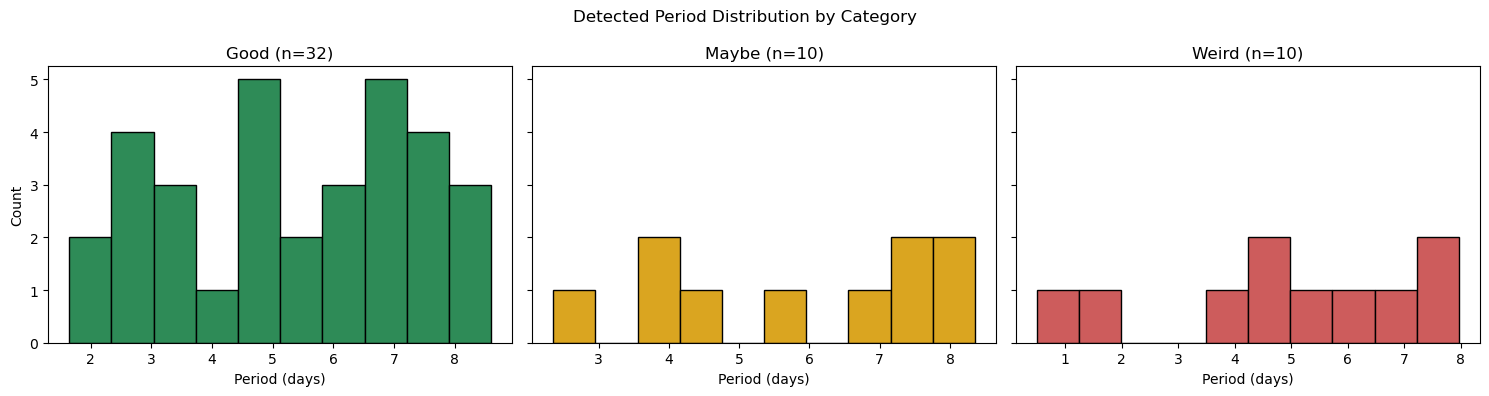

In [5]:
# uploading CSV of results from sheet to make histogram
%matplotlib inline

import pandas as pd
CSV_PATH = "/home/juliajos/good_looking_targets.csv"
data = pd.read_csv(CSV_PATH)
print(data.head())
print(data.columns)

#getting periods based on my list in the CSV
def get_periods(tid_list):
    periods = []
    for tid in tid_list:
        if pd.isna(tid):
            continue
        tid = str(int(tid))
        fpath = os.path.join(RESULTS_DIR, f"{tid}_results.p")
        try:
            with open(fpath, "rb") as f:
                results = pickle.load(f)
            best = results['best_candidates'][0]
            periods.append(best['period_days'])
        except Exception as e:
            print(f"  {tid}: could not load — {e}")
    return periods

good_periods  = get_periods(data['good'])
maybe_periods = get_periods(data['maybe'])
weird_periods = get_periods(data['weird'])

print(f"\nGood:  {len(good_periods)} periods")
print(f"Maybe: {len(maybe_periods)} periods")
print(f"Weird: {len(weird_periods)} periods")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].hist(good_periods, color='seagreen', edgecolor='black')
axes[0].set_title(f'Good (n={len(good_periods)})')
axes[0].set_xlabel('Period (days)')
axes[0].set_ylabel('Count')

axes[1].hist(maybe_periods, color='goldenrod', edgecolor='black')
axes[1].set_title(f'Maybe (n={len(maybe_periods)})')
axes[1].set_xlabel('Period (days)')

axes[2].hist(weird_periods, color='indianred', edgecolor='black')
axes[2].set_title(f'Weird (n={len(weird_periods)})')
axes[2].set_xlabel('Period (days)')

plt.suptitle('Detected Period Distribution by Category')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for saving in a loop

RESULTS_DIR = "/home/juliajos/tess_transit/data/high_snr_results/"
LAB_DIR     = os.path.expanduser("~/tess_transit/data/lightcurves/")
SECTORS     = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]

OUT_DIR = "/home/juliajos/tess_transit/data/good_targets_figures"
os.makedirs(OUT_DIR, exist_ok=True)

good_ids = data['good'].dropna().astype(int).tolist()
print(f"Processing {len(good_ids)} 'good' targets")

for tid in good_ids:
    target = str(tid)
    try:
        # load search results
        results_path = os.path.join(RESULTS_DIR, f"{target}_results.p")
        with open(results_path, "rb") as f:
            results_real = pickle.load(f)

        best_real         = results_real['best_candidates'][0]
        det_period_days   = best_real['period_days']
        det_duration_days = cadence_to_days(best_real['duration'])
        det_t0_btjd       = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])

        # load lightcurve
        lab_path = os.path.join(LAB_DIR, f"{target}.p")
        with open(lab_path, "rb") as f:
            (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
             time_data, cam_data, ccd_data, coeff_ls,
             centroid_xy_data, pos_xy_corr) = pickle.load(f)

        # stitch sectors
        bjd  = np.concatenate([cadences_to_btjd(np.asarray(time_data[s], dtype=float)) for s in SECTORS])
        flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])

        sort_idx = np.argsort(bjd)
        bjd  = bjd[sort_idx]
        flux = flux[sort_idx]

        # set up combined figure: top = stitched lightcurve, bottom = phase fold
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), height_ratios=[1, 1.3])

        # ---------- top: stitched full lightcurve with predicted transit markers ----------
        t_start, t_end = bjd.min(), bjd.max()
        n_min = int(np.floor((t_start - det_t0_btjd) / det_period_days))
        n_max = int(np.ceil((t_end   - det_t0_btjd) / det_period_days))
        transit_times = [det_t0_btjd + n * det_period_days for n in range(n_min, n_max + 1)
                          if t_start <= det_t0_btjd + n * det_period_days <= t_end]

        ax1.plot(bjd, flux, '.', ms=1, color='navy', alpha=0.6)
        for tt in transit_times:
            ax1.axvline(tt, color='red', alpha=0.4, linewidth=0.5, linestyle='--')
        ax1.set_xlabel('BTJD')
        ax1.set_ylabel('Normalized flux')
        ax1.set_title(f'Stitched lightcurve — SNR={best_real["snr"]:.1f}')

        # ---------- bottom: phase folded lightcurve ----------
        phase = ((bjd - det_t0_btjd + 0.5 * det_period_days) % det_period_days) - 0.5 * det_period_days
        phase_norm = phase / det_period_days

        xlim = 0.1
        bin_size = 0.003
        bins = np.arange(-xlim, xlim + bin_size, bin_size)
        b_phase, b_flux = [], []
        for i in range(1, len(bins)):
            mask = (phase_norm >= bins[i-1]) & (phase_norm < bins[i])
            if np.any(mask):
                b_phase.append(0.5 * (bins[i-1] + bins[i]))
                b_flux.append(np.nanmedian(flux[mask]))
        b_phase = np.array(b_phase)
        b_flux  = np.array(b_flux)

        ax2.scatter(phase_norm, flux, s=1, color='gray', alpha=0.2, label='data')
        ax2.plot(b_phase, b_flux, 'D-', ms=4, color='steelblue', label='binned median')
        ax2.axvline(0, color='red', lw=0.8, linestyle='--', label='transit center')
        half_dur = (det_duration_days / det_period_days) / 2
        ax2.axvline(-half_dur, color='red', lw=0.5, linestyle=':')
        ax2.axvline( half_dur, color='red', lw=0.5, linestyle=':')
        ax2.set_xlim(-xlim, xlim)
        ax2.set_xlabel('Phase (fraction of period)')
        ax2.set_ylabel('Flux')
        ax2.set_title(f'Phase fold — P={det_period_days:.4f} d')
        ax2.legend()

        fig.suptitle(f'TIC {target}', fontsize=14)
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"{target}_combined.png"), dpi=150)
        plt.close(fig)

        print(f"  {target}: saved combined figure")

    except Exception as e:
        print(f"  {target}: FAILED — {e}")

    # cleanup
    try:
        del results_real, lc_data, processed_lc_data, detrend_data, norm_offset, quality_data
        del time_data, cam_data, ccd_data, coeff_ls, centroid_xy_data, pos_xy_corr
    except NameError:
        pass
    gc.collect()

print(f"\nDone. Figures saved to {OUT_DIR}")

Processing 32 'good' targets
  160520719: saved combined figure
  160583126: saved combined figure
  198205247: saved combined figure
  199665773: saved combined figure
  199682620: saved combined figure
  199710583: saved combined figure
  219879302: saved combined figure
  229401727: saved combined figure
  229441784: saved combined figure
  229451831: saved combined figure
  229499935: saved combined figure
  229592390: saved combined figure
  229740848: saved combined figure
  229750058: saved combined figure
  229791084: saved combined figure
  229975095: saved combined figure
  230019272: saved combined figure
  230392332: saved combined figure
  233130667: saved combined figure
  233735081: saved combined figure
  236815160: saved combined figure
  259006185: saved combined figure
  264173339: saved combined figure
  279979547: saved combined figure
  389916454: saved combined figure
  389916498: saved combined figure
  392536523: saved combined figure
  394122772: saved combine

## Setting up code to see how many real exoplanets are in our target list to see if we detected them all

In [1]:
import os
import pickle

RESULTS_DIR = "/home/juliajos/tess_transit/data/high_snr_results/"
target_ids = [f.replace("_results.p", "") for f in os.listdir(RESULTS_DIR) if f.endswith("_results.p")]

with open("/home/juliajos/tess_transit/data/our_target_ids.txt", "w") as f:
    for tid in target_ids:
        f.write(f"{tid}\n")

print(f"{len(target_ids)} targets saved")

678 targets saved


In [2]:
import requests
import pandas as pd

# download confirmed planets from NASA Exoplanet Archive
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+tic_id,pl_name,disc_facility+from+pscomppars+where+disc_facility+like+'%TESS%'&format=csv"
response = requests.get(url)

with open("/home/juliajos/tess_transit/data/nasa_tess_planets.csv", "w") as f:
    f.write(response.text)

nasa_df = pd.read_csv("/home/juliajos/tess_transit/data/nasa_tess_planets.csv")
nasa_tic_ids = set(nasa_df['tic_id'].astype(str).str.replace("TIC ", "").dropna())

# find overlap
our_ids = set(target_ids)
found = our_ids & nasa_tic_ids

print(f"Confirmed planets in our target list: {len(found)}")
for tid in found:
    planet = nasa_df[nasa_df['tic_id'].str.contains(tid)]['pl_name'].values
    print(f"  TIC {tid}: {planet}")

Confirmed planets in our target list: 3
  TIC 198360694: <StringArray>
['TOI-2071 b']
Length: 1, dtype: str
  TIC 198186769: <StringArray>
['TOI-1291 b']
Length: 1, dtype: str
  TIC 287139872: <StringArray>
['TOI-1752 b', 'TOI-1752 c']
Length: 2, dtype: str


In [3]:
VETTING_DIR = "/home/juliajos/tess_transit/data/fourth_run_results/"

for tid in found:
    vetting_path = os.path.join(VETTING_DIR, f"{tid}_vetting.p")
    if os.path.exists(vetting_path):
        with open(vetting_path, "rb") as f:
            v = pickle.load(f)
        print(f"TIC {tid}: {v['verdict']}  (score={v['score']:.3g}, SNR={v['snr']:.1f})")
    else:
        print(f"TIC {tid}: no vetting result found")

TIC 198360694: PASSES — no strong evidence from these diagnostics  (score=0.46, SNR=10.8)
TIC 198186769: PASSES — no strong evidence from these diagnostics  (score=0.163, SNR=23.4)
TIC 287139872: FAILS — significant centroid motion detected  (score=0.204, SNR=7.5)


In [4]:
# download TOI list from ExoFOP
url = "https://exofop.ipac.caltech.edu/tess/download_toi.php?sort=toi&output=csv"
response = requests.get(url)

with open("/home/juliajos/tess_transit/data/exofop_tois.csv", "w") as f:
    f.write(response.text)

toi_df = pd.read_csv("/home/juliajos/tess_transit/data/exofop_tois.csv")
print(toi_df.columns.tolist())  # check column names first

['TIC ID', 'TOI', 'Previous CTOI', 'Master', 'SG1A', 'SG1B', 'SG2', 'SG3', 'SG4', 'SG5', 'ESM', 'TSM', 'Predicted Mass (M_Earth)', 'Predicted RV Semi-amplitude (m/s)', 'Time Series Observations', 'Spectroscopy Observations', 'Imaging Observations', 'TESS Disposition', 'TFOPWG Disposition', 'TESS Mag', 'TESS Mag err', 'Planet Name', 'Pipeline Signal ID', 'Source', 'Detection', 'RA', 'Dec', 'PM RA (mas/yr)', 'PM RA err (mas/yr)', 'PM Dec (mas/yr)', 'PM Dec err (mas/yr)', 'Epoch (BJD)', 'Epoch (BJD) err', 'Period (days)', 'Period (days) err', 'Duration (hours)', 'Duration (hours) err', 'Depth (mmag)', 'Depth (mmag) err', 'Depth (ppm)', 'Depth (ppm) err', 'Planet Radius (R_Earth)', 'Planet Radius (R_Earth) err', 'Planet Insolation (Earth Flux)', 'Planet Equil Temp (K)', 'Planet SNR', 'Stellar Distance (pc)', 'Stellar Distance (pc) err', 'Stellar Eff Temp (K)', 'Stellar Eff Temp (K) err', 'Stellar log(g) (cm/s^2)', 'Stellar log(g) (cm/s^2) err', 'Stellar Radius (R_Sun)', 'Stellar Radius (R_

In [5]:
toi_tic_ids = set(toi_df['TIC ID'].astype(str).dropna())

toi_found = our_ids & toi_tic_ids

print(f"TOI candidates in our target list: {len(toi_found)}")
for tid in toi_found:
    rows = toi_df[toi_df['TIC ID'].astype(str) == tid][['TOI', 'TFOPWG Disposition']].values
    for row in rows:
        print(f"  TIC {tid}: TOI {row[0]}  disposition={row[1]}")

TOI candidates in our target list: 70
  TIC 229490898: TOI 1872.01  disposition=PC
  TIC 229791084: TOI 1864.01  disposition=KP
  TIC 233684293: TOI 1791.01  disposition=FA
  TIC 236815160: TOI 1307.01  disposition=APC
  TIC 232632239: TOI 4107.01  disposition=PC
  TIC 320324079: TOI 5202.01  disposition=PC
  TIC 230129753: TOI 4459.01  disposition=PC
  TIC 232628532: TOI 5652.01  disposition=PC
  TIC 219879302: TOI 1884.01  disposition=PC
  TIC 237200747: TOI 1270.01  disposition=FP
  TIC 441739871: TOI 1763.01  disposition=PC
  TIC 229586455: TOI 1887.01  disposition=PC
  TIC 258801269: TOI 1400.01  disposition=FP
  TIC 230017325: TOI 1363.01  disposition=FP
  TIC 441798995: TOI 2269.01  disposition=FA
  TIC 441798995: TOI 2269.02  disposition=PC
  TIC 441798995: TOI 2269.03  disposition=PC
  TIC 236785891: TOI 5956.01  disposition=PC
  TIC 356822426: TOI 4174.01  disposition=PC
  TIC 230387153: TOI 2086.01  disposition=PC
  TIC 230387153: TOI 2086.02  disposition=PC
  TIC 356871098:

In [6]:
disposition_counts = {}
for tid in toi_found:
    rows = toi_df[toi_df['TIC ID'].astype(str) == tid][['TOI', 'TFOPWG Disposition']].values
    for row in rows:
        disp = row[1]
        disposition_counts[disp] = disposition_counts.get(disp, 0) + 1

print("TOI dispositions in our sample:")
for disp, count in sorted(disposition_counts.items()):
    print(f"  {disp}: {count}")

TOI dispositions in our sample:
  APC: 4
  CP: 3
  FA: 5
  FP: 9
  KP: 1
  PC: 55


In [7]:
ground_truth = {'CP', 'KP', 'FP', 'FA'}

print("Ground truth targets:")
for tid in toi_found:
    vetting_path = os.path.join(VETTING_DIR, f"{tid}_vetting.p")
    if not os.path.exists(vetting_path):
        continue
    with open(vetting_path, "rb") as f:
        v = pickle.load(f)
    rows = toi_df[toi_df['TIC ID'].astype(str) == tid][['TOI', 'TFOPWG Disposition']].values
    for row in rows:
        if row[1] in ground_truth:
            print(f"  TIC {tid} TOI {row[0]} ({row[1]}): {v['verdict']}")

Ground truth targets:
  TIC 229791084 TOI 1864.01 (KP): PASSES — no strong evidence from these diagnostics
  TIC 233684293 TOI 1791.01 (FA): FAILS — significant centroid motion detected
  TIC 237200747 TOI 1270.01 (FP): FAILS — significant odd/even depth difference detected
  TIC 258801269 TOI 1400.01 (FP): PASSES — no strong evidence from these diagnostics
  TIC 230017325 TOI 1363.01 (FP): PASSES — no strong evidence from these diagnostics
  TIC 441798995 TOI 2269.01 (FA): PASSES — no strong evidence from these diagnostics
  TIC 259099556 TOI 6069.01 (FA): FAILS — significant centroid motion detected
  TIC 229976631 TOI 4112.01 (FA): FAILS — significant centroid motion detected
  TIC 287139872 TOI 1752.01 (CP): FAILS — significant centroid motion detected
  TIC 287139872 TOI 1752.02 (CP): FAILS — significant centroid motion detected
  TIC 356919658 TOI 1863.01 (FP): FAILS — significant centroid motion detected
  TIC 441732151 TOI 1555.01 (FP): PASSES — no strong evidence from these di

# compiling all the information for the EXOFOP list for future list

In [23]:
# single target example to compile information - orbital period in days, transit midpoint time in BJD, transit depth in ppm

tid = "219879302"

results_path = os.path.join(RESULTS_DIR, f"{tid}_results.p")
with open(results_path, "rb") as f:
    results = pickle.load(f)

best = results['best_candidates'][0]

# load lightcurve
lab_path = os.path.join(LAB_DIR, f"{tid}.p")
with open(lab_path, "rb") as f:
    (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
     time_data, cam_data, ccd_data, coeff_ls,
     centroid_xy_data, pos_xy_corr) = pickle.load(f)

period_days       = best['period_days']
det_duration_days = cadence_to_days(best['duration'])

t0_btjd = epoch_to_btjd(best['epoch_cadences'], best['duration'])  # no offset
t0_bjd  = epoch_to_btjd(sector73_start_cad + best['epoch_cadences'], best['duration']) + 2457000  # offset only for BJD

cad  = np.concatenate([np.asarray(time_data[s]) for s in SECTORS])
flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])
bjd  = cadences_to_btjd(cad)

all_raw     = np.concatenate([np.array(lc_data[s].unmasked) for s in SECTORS if s in lc_data])
norm_factor = np.nanmedian(all_raw)

# phase fold
phase      = ((bjd - t0_btjd + 0.5 * period_days) % period_days) - 0.5 * period_days
phase_norm = phase / period_days

# bin the phase-folded flux
bin_size = 0.003
bins = np.arange(-0.5, 0.5 + bin_size, bin_size)
b_phase, b_flux = [], []
for i in range(1, len(bins)):
    bin_mask = (phase_norm >= bins[i-1]) & (phase_norm < bins[i])
    if np.any(bin_mask):
        b_phase.append(0.5 * (bins[i-1] + bins[i]))
        b_flux.append(np.nanmedian(flux[bin_mask]))
b_phase = np.array(b_phase)
b_flux  = np.array(b_flux)

# depth from minimum binned flux near transit center
half_dur      = (det_duration_days / period_days) / 2
near_transit  = np.abs(b_phase) < 2 * half_dur
transit_min   = np.nanmin(b_flux[near_transit])
baseline_flux = np.nanmedian(b_flux[~near_transit])

depth_fraction  = (baseline_flux - transit_min) / norm_factor
depth_ppm       = abs(depth_fraction) * 1e6
rp_rs           = np.sqrt(abs(depth_fraction))

# error from scatter of binned flux in baseline
depth_error     = np.nanstd(b_flux[~near_transit]) / norm_factor * 1e6

print(f"TIC {tid}:")
print(f"  Depth: {depth_ppm:.2f} ± {depth_error:.2f} ppm")
print(f"  R_p/R_s: {rp_rs:.4f} ({rp_rs*100:.2f}%)")
print(f"  Period: {period_days:.4f} days")
print(f"  Transit midpoint (BJD): {t0_bjd:.5f}")
print(f"  Duration: {det_duration_days:.4f} days ({det_duration_days*24:.2f} hours)")

TIC 219879302:
  Depth: 8376.36 ± 366.85 ppm
  R_p/R_s: 0.0915 (9.15%)
  Period: 6.7847 days
  Transit midpoint (BJD): 2459059.84444
  Duration: 0.1250 days (3.00 hours)


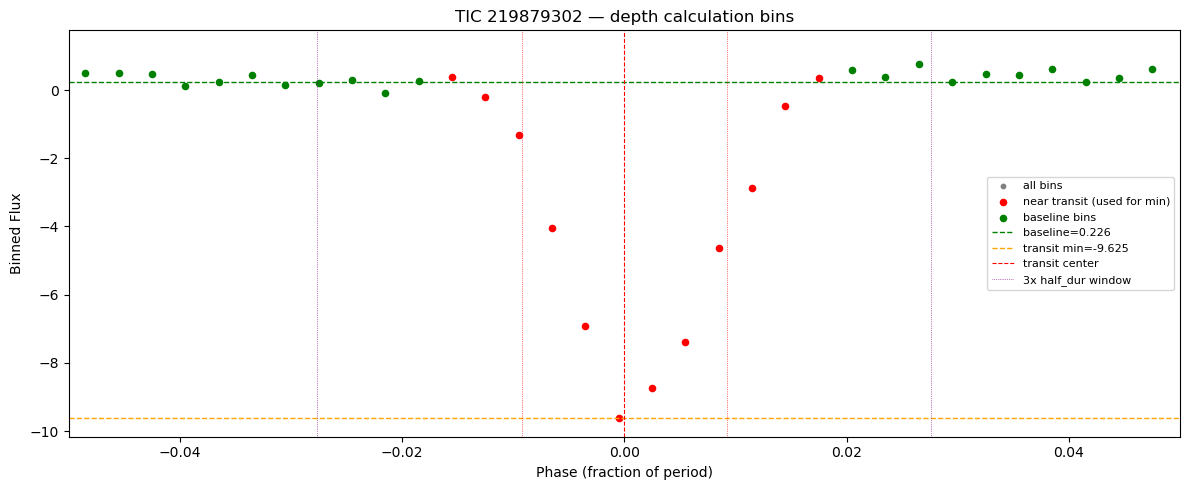

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(b_phase, b_flux, s=10, color='gray', label='all bins')
ax.scatter(b_phase[near_transit], b_flux[near_transit], s=20, color='red', label='near transit (used for min)')
ax.scatter(b_phase[~near_transit], b_flux[~near_transit], s=20, color='green', label='baseline bins')
ax.axhline(baseline_flux, color='green', lw=1, linestyle='--', label=f'baseline={baseline_flux:.3f}')
ax.axhline(transit_min, color='orange', lw=1, linestyle='--', label=f'transit min={transit_min:.3f}')
ax.axvline(0, color='red', lw=0.8, linestyle='--', label='transit center')
ax.axvline(-half_dur, color='red', lw=0.5, linestyle=':')
ax.axvline( half_dur, color='red', lw=0.5, linestyle=':')
ax.axvline(-3*half_dur, color='purple', lw=0.5, linestyle=':', label='3x half_dur window')
ax.axvline( 3*half_dur, color='purple', lw=0.5, linestyle=':')
ax.set_xlim(-0.05, 0.05)
ax.set_xlabel('Phase (fraction of period)')
ax.set_ylabel('Binned Flux')
ax.set_title(f'TIC {tid} — depth calculation bins')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
import csv
output_csv = "/home/juliajos/tess_transit/data/exofop_submission.csv"
VETTING_DIR = "/home/juliajos/tess_transit/data/fourth_run_results/"

with open(output_csv, "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['TIC ID', 'Period (days)', 'Transit Midpoint (BJD)', 'Depth (ppm)', 'Depth Error (ppm)', 'Rp/Rs'])

    for fname in os.listdir(VETTING_DIR):
        if not fname.endswith("_vetting.p"):
            continue
        with open(os.path.join(VETTING_DIR, fname), "rb") as vf:
            v = pickle.load(vf)
        if "PASSES" not in v['verdict']:
            continue

        tid = v['target_id']
        print(f"Processing TIC {tid}...")

        try:
            results_path = os.path.join(RESULTS_DIR, f"{tid}_results.p")
            with open(results_path, "rb") as rf:
                results = pickle.load(rf)
            best = results['best_candidates'][0]

            lab_path = os.path.join(LAB_DIR, f"{tid}.p")
            with open(lab_path, "rb") as lf:
                (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
                 time_data, cam_data, ccd_data, coeff_ls,
                 centroid_xy_data, pos_xy_corr) = pickle.load(lf)

            period_days       = best['period_days']
            det_duration_days = cadence_to_days(best['duration'])
            t0_btjd = epoch_to_btjd(best['epoch_cadences'], best['duration'])
            t0_bjd  = t0_btjd + 2457000
            cad  = np.concatenate([np.asarray(time_data[s]) for s in SECTORS])
            flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])
            bjd  = cadences_to_btjd(cad)

            all_raw     = np.concatenate([np.array(lc_data[s].unmasked) for s in SECTORS if s in lc_data])
            norm_factor = np.nanmedian(all_raw)

            # phase fold
            phase      = ((bjd - t0_btjd + 0.5 * period_days) % period_days) - 0.5 * period_days
            phase_norm = phase / period_days

            bin_size = 0.003
            bins = np.arange(-0.5, 0.5 + bin_size, bin_size)
            b_phase, b_flux = [], []
            for i in range(1, len(bins)):
                bin_mask = (phase_norm >= bins[i-1]) & (phase_norm < bins[i])
                if np.any(bin_mask):
                    b_phase.append(0.5 * (bins[i-1] + bins[i]))
                    b_flux.append(np.nanmedian(flux[bin_mask]))
            b_phase = np.array(b_phase)
            b_flux  = np.array(b_flux)

            half_dur      = (det_duration_days / period_days) / 2
            near_transit  = np.abs(b_phase) < 2 * half_dur
            transit_min   = np.nanmin(b_flux[near_transit])
            baseline_flux = np.nanmedian(b_flux[~near_transit])

            depth_fraction = (baseline_flux - transit_min) / norm_factor
            depth_ppm      = abs(depth_fraction) * 1e6
            depth_error    = np.nanstd(b_flux[~near_transit]) / norm_factor * 1e6
            rp_rs          = np.sqrt(abs(depth_fraction))

            writer.writerow([tid, f"{period_days:.6f}", f"{t0_bjd:.6f}",
                             f"{depth_ppm:.1f}", f"{depth_error:.1f}", f"{rp_rs:.4f}"])

        except Exception as e:
            print(f"  Skipping {tid}: {e}")
            continue

print(f"\nDone. Results saved to {output_csv}")

Processing TIC 230136419...
Processing TIC 198360694...
Processing TIC 462615350...
Processing TIC 356822426...
Processing TIC 229975095...
Processing TIC 233735081...
Processing TIC 229441784...
Processing TIC 279979547...
Processing TIC 287139950...
Processing TIC 229644935...
Processing TIC 359584313...
Processing TIC 230081514...
Processing TIC 356916207...
Processing TIC 376977731...
Processing TIC 392536523...
Processing TIC 229744080...
Processing TIC 232621086...
Processing TIC 259006185...
Processing TIC 233627309...
Processing TIC 229411621...
Processing TIC 383675945...
Processing TIC 199660910...
Processing TIC 229687624...
Processing TIC 389916498...
Processing TIC 219878010...
Processing TIC 359629653...
Processing TIC 243278290...
Processing TIC 264221104...
Processing TIC 233087496...
Processing TIC 224605072...
Processing TIC 229451831...
Processing TIC 229740848...
Processing TIC 272786592...
Processing TIC 230129793...
Processing TIC 280031353...
Processing TIC 23001

In [10]:
import pandas as pd

df = pd.read_csv("/home/juliajos/tess_transit/data/exofop_submission.csv")
df['Depth SNR'] = df['Depth (ppm)'] / df['Depth Error (ppm)']

# planet candidates: Rp/Rs < 0.15 (15%)
planets = df[df['Rp/Rs'] < 0.15].sort_values('Depth (ppm)', ascending=False)
likely_fp = df[df['Rp/Rs'] >= 0.15]

print(f"Total targets:          {len(df)}")
print(f"Likely planets (<15%):  {len(planets)}")
print(f"Likely FP (>15%):       {len(likely_fp)}")
print()
print(planets[['TIC ID', 'Period (days)', 'Depth (ppm)', 'Depth Error (ppm)', 'Rp/Rs', 'Depth SNR']].to_string())

Total targets:          160
Likely planets (<15%):  150
Likely FP (>15%):       10

         TIC ID  Period (days)  Depth (ppm)  Depth Error (ppm)   Rp/Rs  Depth SNR
29    224605072       6.979167      19503.5            52491.3  0.1397   0.371557
22    229687624       4.562500      18851.4            16469.8  0.1373   1.144604
116   356701798       0.534722      13757.1             5296.1  0.1173   2.597591
106  1271099724       8.055556      11441.0             7907.7  0.1070   1.446818
60    233503147       6.743056      10858.2            47297.8  0.1042   0.229571
158   356893006       7.423611      10404.9            59576.0  0.1020   0.174649
147   441799484       1.909722       8018.1            15269.8  0.0895   0.525095
55    219759788       3.881944       7535.7            15029.8  0.0868   0.501384
130   389916454       4.944444       7101.8            77332.6  0.0843   0.091834
4     229975095       7.777778       6856.3             4815.5  0.0828   1.423798
13    37697773

In [11]:
# strong detections with depth SNR > 3 and Rp/Rs < 0.15
strong = planets[planets['Depth SNR'] > 3].sort_values('Depth SNR', ascending=False)
print(f"Strong detections (SNR > 3, Rp/Rs < 15%): {len(strong)}")
print(strong[['TIC ID', 'Period (days)', 'Depth (ppm)', 'Rp/Rs', 'Depth SNR']].to_string())

Strong detections (SNR > 3, Rp/Rs < 15%): 7
         TIC ID  Period (days)  Depth (ppm)   Rp/Rs  Depth SNR
123  1717869359       2.534722       4275.3  0.0654   6.116309
138   236815160       2.534722       4232.8  0.0651   6.065921
3     356822426       7.784722       1086.0  0.0330   3.747412
134   362225801       4.152778       3123.0  0.0559   3.594200
19    229411621       1.770833        185.4  0.0136   3.340541
127   356979069       0.534722        236.3  0.0154   3.159091
96    237200740       5.291667        768.9  0.0277   3.041535


# making new figures to include the transit depth and rp/rstar in the figures

depth_ppm: 193.1
rp_rs:     0.0139 (1.39%)


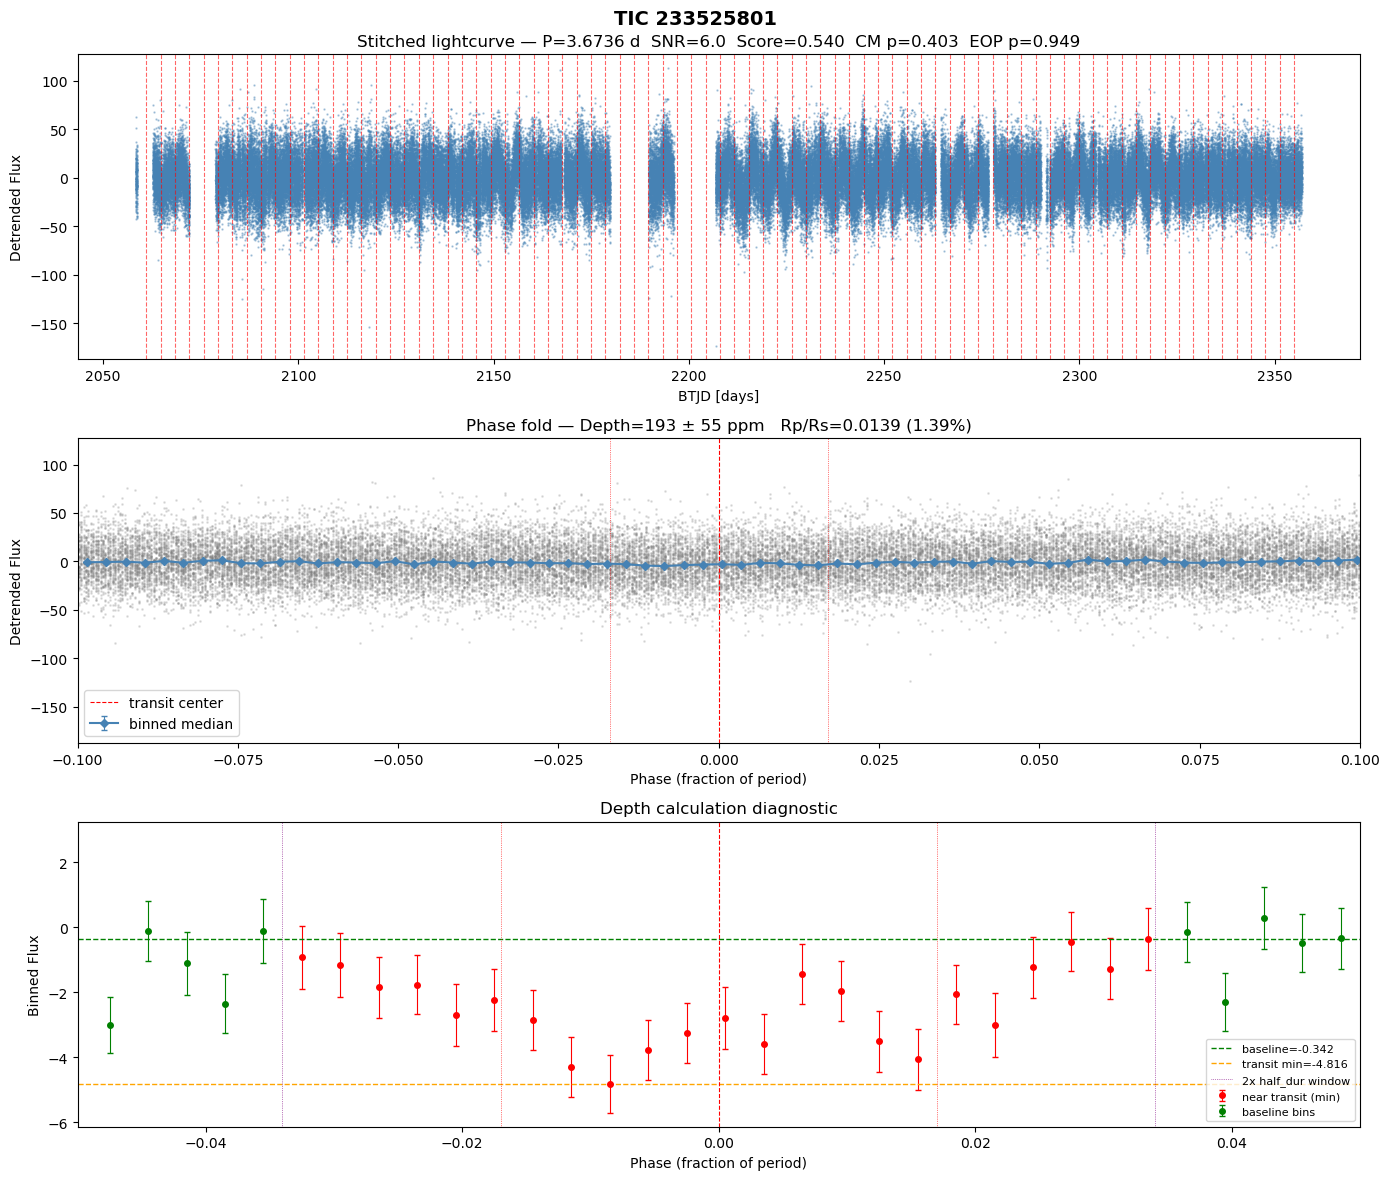

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt

OUT_DIR = "/home/juliajos/tess_transit/data/high_snr_phase_fold_passed_vetting"
os.makedirs(OUT_DIR, exist_ok=True)

VETTING_DIR = "/home/juliajos/tess_transit/data/fourth_run_results/"

def plot_lc_phase_fold_diagnostic(target, time_btjd, flux, period_days, t0_btjd, duration_days,
                                   depth_ppm, depth_error, rp_rs, snr, norm_factor, vetting_score,
                                   cm_p, eop_p, xlim=0.1, bin_size=0.003, save_path=None):
    # phase fold
    phase      = ((time_btjd - t0_btjd + 0.5 * period_days) % period_days) - 0.5 * period_days
    phase_norm = phase / period_days

    # bins for full phase fold
    bins = np.arange(-xlim, xlim + bin_size, bin_size)
    b_phase, b_flux, b_err = [], [], []
    for i in range(1, len(bins)):
        mask = (phase_norm >= bins[i-1]) & (phase_norm < bins[i])
        if np.any(mask):
            b_phase.append(0.5 * (bins[i-1] + bins[i]))
            b_flux.append(np.nanmedian(flux[mask]))
            b_err.append(np.nanstd(flux[mask]) / np.sqrt(np.sum(mask)))
    b_phase = np.array(b_phase)
    b_flux  = np.array(b_flux)
    b_err   = np.array(b_err)

    # depth calculation
    half_dur      = (duration_days / period_days) / 2
    near_transit  = np.abs(b_phase) < 2 * half_dur
    transit_min   = np.nanmin(b_flux[near_transit])
    baseline_flux = np.nanmedian(b_flux[~near_transit])

    # predicted transit times
    t_start, t_end = time_btjd.min(), time_btjd.max()
    n_min = int(np.floor((t_start - t0_btjd) / period_days))
    n_max = int(np.ceil((t_end   - t0_btjd) / period_days))
    transit_times = [t0_btjd + n * period_days for n in range(n_min, n_max + 1)
                     if t_start <= t0_btjd + n * period_days <= t_end]

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle(f'TIC {target}', fontsize=14, fontweight='bold')

    # top: stitched lightcurve
    ax1.scatter(time_btjd, flux, s=0.5, alpha=0.4, color='steelblue')
    for tt in transit_times:
        ax1.axvline(tt, color='red', lw=0.8, alpha=0.6, linestyle='--')
    ax1.set_xlabel('BTJD [days]')
    ax1.set_ylabel('Detrended Flux')
    ax1.set_title(f'Stitched lightcurve — P={period_days:.4f} d  SNR={snr:.1f}  '
                  f'Score={vetting_score:.3f}  CM p={cm_p:.3g}  EOP p={eop_p:.3g}')

    # middle: phase fold
    ax2.scatter(phase_norm, flux, s=1, color='gray', alpha=0.2)
    ax2.errorbar(b_phase, b_flux, yerr=b_err, fmt='D-', ms=4, color='steelblue',
                 ecolor='steelblue', elinewidth=0.8, capsize=2, label='binned median')
    ax2.axvline(0, color='red', lw=0.8, linestyle='--', label='transit center')
    ax2.axvline(-half_dur, color='red', lw=0.5, linestyle=':')
    ax2.axvline( half_dur, color='red', lw=0.5, linestyle=':')
    ax2.set_xlim(-xlim, xlim)
    ax2.set_xlabel('Phase (fraction of period)')
    ax2.set_ylabel('Detrended Flux')
    ax2.set_title(f'Phase fold — Depth={depth_ppm:.0f} ± {depth_error:.0f} ppm   Rp/Rs={rp_rs:.4f} ({rp_rs*100:.2f}%)')
    ax2.legend()

    # bottom: diagnostic bins
    ax3.errorbar(b_phase[near_transit], b_flux[near_transit], yerr=b_err[near_transit],
                 fmt='o', ms=4, color='red', ecolor='red', elinewidth=0.8, capsize=2, label='near transit (min)')
    ax3.errorbar(b_phase[~near_transit], b_flux[~near_transit], yerr=b_err[~near_transit],
                 fmt='o', ms=4, color='green', ecolor='green', elinewidth=0.8, capsize=2, label='baseline bins')
    ax3.axhline(baseline_flux, color='green', lw=1, linestyle='--', label=f'baseline={baseline_flux:.3f}')
    ax3.axhline(transit_min, color='orange', lw=1, linestyle='--', label=f'transit min={transit_min:.3f}')
    ax3.axvline(0, color='red', lw=0.8, linestyle='--')
    ax3.axvline(-half_dur, color='red', lw=0.5, linestyle=':')
    ax3.axvline( half_dur, color='red', lw=0.5, linestyle=':')
    ax3.axvline(-2*half_dur, color='purple', lw=0.5, linestyle=':', label='2x half_dur window')
    ax3.axvline( 2*half_dur, color='purple', lw=0.5, linestyle=':')
    ax3.set_xlim(-0.05, 0.05)
    ax3.set_xlabel('Phase (fraction of period)')
    ax3.set_ylabel('Binned Flux')
    ax3.set_title('Depth calculation diagnostic')
    ax3.legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        plt.close(fig)
    else:
        plt.show()


target = "233525801"

# load vetting results
vetting_path = os.path.join(VETTING_DIR, f"{target}_vetting.p")
with open(vetting_path, "rb") as f:
    v = pickle.load(f)
vetting_score = v['score']
cm_p          = v['combined_cm_p']
eop_p         = v['combined_eop_p']

results_path = os.path.join(RESULTS_DIR, f"{target}_results.p")
with open(results_path, "rb") as f:
    results_real = pickle.load(f)

best_real         = results_real['best_candidates'][0]
det_period_days   = best_real['period_days'] 
det_duration_days = cadence_to_days(best_real['duration'])
det_t0_btjd       = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])
snr               = best_real['snr']

lab_path = os.path.join(LAB_DIR, f"{target}.p")
with open(lab_path, "rb") as f:
    (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
     time_data, cam_data, ccd_data, coeff_ls,
     centroid_xy_data, pos_xy_corr) = pickle.load(f)

bjd  = np.concatenate([cadences_to_btjd(np.asarray(time_data[s], dtype=float)) for s in SECTORS])
flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])
sort_idx = np.argsort(bjd)
bjd  = bjd[sort_idx]
flux = flux[sort_idx]

all_raw     = np.concatenate([np.array(lc_data[s].unmasked) for s in SECTORS if s in lc_data])
norm_factor = np.nanmedian(all_raw)

# phase fold for depth
phase      = ((bjd - det_t0_btjd + 0.5 * det_period_days) % det_period_days) - 0.5 * det_period_days
phase_norm = phase / det_period_days
bin_size   = 0.003
bins       = np.arange(-0.5, 0.5 + bin_size, bin_size)
b_phase, b_flux, b_err = [], [], []
for i in range(1, len(bins)):
    bin_mask = (phase_norm >= bins[i-1]) & (phase_norm < bins[i])
    if np.any(bin_mask):
        b_phase.append(0.5 * (bins[i-1] + bins[i]))
        b_flux.append(np.nanmedian(flux[bin_mask]))
        b_err.append(np.nanstd(flux[bin_mask]) / np.sqrt(np.sum(bin_mask)))
b_phase = np.array(b_phase)
b_flux  = np.array(b_flux)
b_err   = np.array(b_err)

half_dur      = (det_duration_days / det_period_days) / 2
near_transit  = np.abs(b_phase) < 2 * half_dur
transit_min   = np.nanmin(b_flux[near_transit])
baseline_flux = np.nanmedian(b_flux[~near_transit])

depth_fraction = (baseline_flux - transit_min) / norm_factor
depth_ppm      = abs(depth_fraction) * 1e6
depth_error    = np.nanstd(b_flux[~near_transit]) / norm_factor * 1e6
rp_rs          = np.sqrt(abs(depth_fraction))

print(f"depth_ppm: {depth_ppm:.1f}")
print(f"rp_rs:     {rp_rs:.4f} ({rp_rs*100:.2f}%)")

plot_lc_phase_fold_diagnostic(target, bjd, flux, det_period_days, det_t0_btjd,
                               det_duration_days, depth_ppm, depth_error, rp_rs, snr, norm_factor,
                               vetting_score, cm_p, eop_p, save_path=None)

In [ ]:
#running over all targets now
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import gc
import os
import pickle
import numpy as np

OUT_DIR     = "/home/juliajos/tess_transit/data/high_snr_phase_fold_passed_vetting"
VETTING_DIR = "/home/juliajos/tess_transit/data/fourth_run_results/"
RESULTS_DIR = "/home/juliajos/tess_transit/data/high_snr_results/"
LAB_DIR     = os.path.expanduser("~/tess_transit/data/lightcurves/")
SECTORS     = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
os.makedirs(OUT_DIR, exist_ok=True)

CADENCE_DURATION_DAYS = 2 / (24 * 60)

def cadence_to_days(n): return n * CADENCE_DURATION_DAYS
def cadences_to_btjd(c): return c * (120 / 86400)
def epoch_to_btjd(epoch, duration): return (epoch + duration / 2) * (120 / 86400)

def plot_lc_phase_fold_diagnostic(target, time_btjd, flux, period_days, t0_btjd, duration_days,
                                   depth_ppm, depth_error, rp_rs, snr, norm_factor, vetting_score,
                                   cm_p, eop_p, xlim=0.1, bin_size=0.003, save_path=None):
    phase      = ((time_btjd - t0_btjd + 0.5 * period_days) % period_days) - 0.5 * period_days
    phase_norm = phase / period_days

    bins = np.arange(-xlim, xlim + bin_size, bin_size)
    b_phase, b_flux, b_err = [], [], []
    for i in range(1, len(bins)):
        mask = (phase_norm >= bins[i-1]) & (phase_norm < bins[i])
        if np.any(mask):
            b_phase.append(0.5 * (bins[i-1] + bins[i]))
            b_flux.append(np.nanmedian(flux[mask]))
            b_err.append(np.nanstd(flux[mask]) / np.sqrt(np.sum(mask)))
    b_phase = np.array(b_phase)
    b_flux  = np.array(b_flux)
    b_err   = np.array(b_err)

    half_dur      = (duration_days / period_days) / 2
    near_transit  = np.abs(b_phase) < 2 * half_dur
    transit_min   = np.nanmin(b_flux[near_transit])
    baseline_flux = np.nanmedian(b_flux[~near_transit])

    t_start, t_end = time_btjd.min(), time_btjd.max()
    n_min = int(np.floor((t_start - t0_btjd) / period_days))
    n_max = int(np.ceil((t_end   - t0_btjd) / period_days))
    transit_times = [t0_btjd + n * period_days for n in range(n_min, n_max + 1)
                     if t_start <= t0_btjd + n * period_days <= t_end]

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle(f'TIC {target}', fontsize=14, fontweight='bold')

    ax1.scatter(time_btjd, flux, s=0.5, alpha=0.4, color='steelblue')
    for tt in transit_times:
        ax1.axvline(tt, color='red', lw=0.8, alpha=0.6, linestyle='--')
    ax1.set_xlabel('BTJD [days]')
    ax1.set_ylabel('Detrended Flux')
    ax1.set_title(f'Stitched lightcurve — P={period_days:.4f} d  SNR={snr:.1f}  '
                  f'Score={vetting_score:.3f}  CM p={cm_p:.3g}  EOP p={eop_p:.3g}')

    ax2.scatter(phase_norm, flux, s=1, color='gray', alpha=0.2)
    ax2.errorbar(b_phase, b_flux, yerr=b_err, fmt='D-', ms=4, color='steelblue',
                 ecolor='steelblue', elinewidth=0.8, capsize=2, label='binned median')
    ax2.axvline(0, color='red', lw=0.8, linestyle='--', label='transit center')
    ax2.axvline(-half_dur, color='red', lw=0.5, linestyle=':')
    ax2.axvline( half_dur, color='red', lw=0.5, linestyle=':')
    ax2.set_xlim(-xlim, xlim)
    ax2.set_xlabel('Phase (fraction of period)')
    ax2.set_ylabel('Detrended Flux')
    ax2.set_title(f'Phase fold — Depth={depth_ppm:.0f} ± {depth_error:.0f} ppm   Rp/Rs={rp_rs:.4f} ({rp_rs*100:.2f}%)')
    ax2.legend()

    ax3.errorbar(b_phase[near_transit], b_flux[near_transit], yerr=b_err[near_transit],
                 fmt='o', ms=4, color='red', ecolor='red', elinewidth=0.8, capsize=2, label='near transit (min)')
    ax3.errorbar(b_phase[~near_transit], b_flux[~near_transit], yerr=b_err[~near_transit],
                 fmt='o', ms=4, color='green', ecolor='green', elinewidth=0.8, capsize=2, label='baseline bins')
    ax3.axhline(baseline_flux, color='green', lw=1, linestyle='--', label=f'baseline={baseline_flux:.3f}')
    ax3.axhline(transit_min, color='orange', lw=1, linestyle='--', label=f'transit min={transit_min:.3f}')
    ax3.axvline(0, color='red', lw=0.8, linestyle='--')
    ax3.axvline(-half_dur, color='red', lw=0.5, linestyle=':')
    ax3.axvline( half_dur, color='red', lw=0.5, linestyle=':')
    ax3.axvline(-2*half_dur, color='purple', lw=0.5, linestyle=':', label='2x half_dur window')
    ax3.axvline( 2*half_dur, color='purple', lw=0.5, linestyle=':')
    ax3.set_xlim(-0.05, 0.05)
    ax3.set_xlabel('Phase (fraction of period)')
    ax3.set_ylabel('Binned Flux')
    ax3.set_title('Depth calculation diagnostic')
    ax3.legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        plt.close(fig)
    else:
        plt.show()


# get all passing targets
passing_ids = []
for fname in os.listdir(VETTING_DIR):
    if not fname.endswith("_vetting.p"):
        continue
    with open(os.path.join(VETTING_DIR, fname), "rb") as f:
        v = pickle.load(f)
    if "PASSES" in v['verdict']:
        passing_ids.append(v['target_id'])

print(f"Found {len(passing_ids)} passing targets")

for target in passing_ids:
    print(f"Processing TIC {target}...")
    try:
        vetting_path = os.path.join(VETTING_DIR, f"{target}_vetting.p")
        with open(vetting_path, "rb") as f:
            v = pickle.load(f)
        vetting_score = v['score']
        cm_p          = v['combined_cm_p']
        eop_p         = v['combined_eop_p']

        results_path = os.path.join(RESULTS_DIR, f"{target}_results.p")
        with open(results_path, "rb") as f:
            results_real = pickle.load(f)
        best_real         = results_real['best_candidates'][0]
        det_period_days   = best_real['period_days']
        det_duration_days = cadence_to_days(best_real['duration'])
        det_t0_btjd       = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])
        snr               = best_real['snr']

        lab_path = os.path.join(LAB_DIR, f"{target}.p")
        with open(lab_path, "rb") as f:
            (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
             time_data, cam_data, ccd_data, coeff_ls,
             centroid_xy_data, pos_xy_corr) = pickle.load(f)

        bjd  = np.concatenate([cadences_to_btjd(np.asarray(time_data[s], dtype=float)) for s in SECTORS])
        flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])
        sort_idx = np.argsort(bjd)
        bjd  = bjd[sort_idx]
        flux = flux[sort_idx]

        all_raw     = np.concatenate([np.array(lc_data[s].unmasked) for s in SECTORS if s in lc_data])
        norm_factor = np.nanmedian(all_raw)

        phase      = ((bjd - det_t0_btjd + 0.5 * det_period_days) % det_period_days) - 0.5 * det_period_days
        phase_norm = phase / det_period_days
        bin_size   = 0.003
        bins       = np.arange(-0.5, 0.5 + bin_size, bin_size)
        b_phase, b_flux, b_err = [], [], []
        for i in range(1, len(bins)):
            bin_mask = (phase_norm >= bins[i-1]) & (phase_norm < bins[i])
            if np.any(bin_mask):
                b_phase.append(0.5 * (bins[i-1] + bins[i]))
                b_flux.append(np.nanmedian(flux[bin_mask]))
                b_err.append(np.nanstd(flux[bin_mask]) / np.sqrt(np.sum(bin_mask)))
        b_phase = np.array(b_phase)
        b_flux  = np.array(b_flux)
        b_err   = np.array(b_err)

        half_dur      = (det_duration_days / det_period_days) / 2
        near_transit  = np.abs(b_phase) < 2 * half_dur
        transit_min   = np.nanmin(b_flux[near_transit])
        baseline_flux = np.nanmedian(b_flux[~near_transit])

        depth_fraction = (baseline_flux - transit_min) / norm_factor
        depth_ppm      = abs(depth_fraction) * 1e6
        depth_error    = np.nanstd(b_flux[~near_transit]) / norm_factor * 1e6
        rp_rs          = np.sqrt(abs(depth_fraction))

        save_path = os.path.join(OUT_DIR, f"{target}_lc_phase_fold.png")
        plot_lc_phase_fold_diagnostic(target, bjd, flux, det_period_days, det_t0_btjd,
                                       det_duration_days, depth_ppm, depth_error, rp_rs, snr,
                                       norm_factor, vetting_score, cm_p, eop_p, save_path=save_path)
        print(f"  Saved — depth={depth_ppm:.0f} ppm, Rp/Rs={rp_rs:.4f}")

    except Exception as e:
        print(f"  Skipping {target}: {e}")
        continue
    finally:
        try:
            del lc_data, processed_lc_data, detrend_data, norm_offset, quality_data
            del time_data, cam_data, ccd_data, coeff_ls, centroid_xy_data, pos_xy_corr
            del results_real
        except:
            pass
        gc.collect()

print(f"\nAll done — saved to {OUT_DIR}")

Found 160 passing targets
Processing TIC 230136419...
  Saved — depth=284 ppm, Rp/Rs=0.0168
Processing TIC 198360694...
  Saved — depth=803 ppm, Rp/Rs=0.0283
Processing TIC 462615350...
  Saved — depth=1943 ppm, Rp/Rs=0.0441
Processing TIC 356822426...


KeyboardInterrupt: 

# Exploring the distributiom of the good and weird targets after going through the spreadsheet after making the above plots and implementing the vetting cutoffs

In [ ]:
import pandas as pd

df = pd.read_csv("/home/juliajos/tess_transit/data/exofop_submission.csv")

# for tids in the "change period" column
correct_periods = {
    '160583126': 6.998,
    '229750058': 10.1824,
    '267542728': 39.74,
    '356822426': 1.5569,
    '356978132': 60.184,
    '359629653': 1.67,
}

for tid, correct_p in correct_periods.items():
    row = df[df['TIC ID'] == int(tid)]
    if len(row) > 0:
        detected_p = row['Period (days)'].values[0]
        ratio = correct_p / detected_p
        print(f"TIC {tid}: detected={detected_p:.4f}, correct={correct_p:.4f}, ratio={ratio:.3f}")
    

TIC 160583126: detected=2.3472, correct=6.9980, ratio=2.981
TIC 229750058: detected=5.0903, correct=10.1824, ratio=2.000
TIC 267542728: detected=7.9583, correct=39.7400, ratio=4.994
TIC 356822426: detected=7.7847, correct=1.5569, ratio=0.200
TIC 356978132: detected=8.5972, correct=60.1840, ratio=7.000
TIC 359629653: detected=8.3542, correct=1.6700, ratio=0.200


In [ ]:
# for candidates that ARE confirmed in exofop, compare their periods to the ones we detected and see if they are harmonics or not (most are)
good_tics_periods = {
    '160520719': 2.2778,
    '219879302': 6.7847,
    '229750058': 10.1,
    '236815160': 2.5347,
    '258801269': 5.4931,
    '267542728': 7.958,
    '356822426': 7.7847,
    '356978132': 8.5972,
    '359629653': 8.3542,
    '462615350': 8.9167,
}

exofop_periods = {
    '219879302': 6.7822,
    '229750058': 10.18,
    '236815160': 2.5397,
    '258801269': 5.48923,
    '267542728': 39.74,
    '356822426': 1.5569,
    '356978132': 60.18,
    '359629653': 1.67,
    '462615350': 8.91722,
}

print("Period comparison for good targets in ExoFOP:")
for tid in good_tics_periods:
    if tid in exofop_periods:
        my_p = good_tics_periods[tid]
        ex_p = exofop_periods[tid]
        ratio = ex_p / my_p
        print(f"  TIC {tid}: mine={my_p:.4f}d, ExoFOP={ex_p:.4f}d, ratio={ratio:.3f}")
    else:
        print(f"  TIC {tid}: mine={good_tics_periods[tid]:.4f}d — not in ExoFOP")

Period comparison for good targets in ExoFOP:
  TIC 160520719: mine=2.2778d — not in ExoFOP
  TIC 219879302: mine=6.7847d, ExoFOP=6.7822d, ratio=1.000
  TIC 229750058: mine=10.1000d, ExoFOP=10.1800d, ratio=1.008
  TIC 236815160: mine=2.5347d, ExoFOP=2.5397d, ratio=1.002
  TIC 258801269: mine=5.4931d, ExoFOP=5.4892d, ratio=0.999
  TIC 267542728: mine=7.9580d, ExoFOP=39.7400d, ratio=4.994
  TIC 356822426: mine=7.7847d, ExoFOP=1.5569d, ratio=0.200
  TIC 356978132: mine=8.5972d, ExoFOP=60.1800d, ratio=7.000
  TIC 359629653: mine=8.3542d, ExoFOP=1.6700d, ratio=0.200
  TIC 462615350: mine=8.9167d, ExoFOP=8.9172d, ratio=1.000


In [5]:
import os
import pickle
import numpy as np

VETTING_DIR = "/home/juliajos/tess_transit/data/fourth_run_results/"

both_pass = 0
total_passing = 0

for fname in os.listdir(VETTING_DIR):
    if not fname.endswith("_vetting.p"):
        continue
    with open(os.path.join(VETTING_DIR, fname), "rb") as f:
        v = pickle.load(f)
    
    if "PASSES" not in v['verdict']:
        continue
    
    total_passing += 1
    cm_p  = v['combined_cm_p']
    eop_p = v['combined_eop_p']
    
    if np.isfinite(cm_p) and np.isfinite(eop_p) and cm_p >= 0.05 and eop_p >= 0.05:
        both_pass += 1

print(f"Total passing vetting:              {total_passing}")
print(f"Both CM and EOP p >= 0.05:          {both_pass}")
print(f"Passed on weighted score only:      {total_passing - both_pass}")

Total passing vetting:              160
Both CM and EOP p >= 0.05:          105
Passed on weighted score only:      55


# creating a function to count the number of transits to see if period needs adjusting

In [7]:
def find_correct_period(bjd, flux, det_period_days, t0_btjd, duration_days, 
                         multiples=[2, 3, 4, 5, 6, 7], zero_threshold=0.3):
    """
    Checks integer multiples AND fractions of the detected period to find the true period.
    For each candidate period, looks at each predicted transit location and computes the 
    sum of flux points. If the sum is close to zero, the transit is likely not real.
    The period with the highest fraction of real transits is returned as the best period.
    Based on methodology suggested by Dr. Taaki.
    """
    # get all candidate periods including detected, multiples, and fractions
    candidate_periods = {'1x': det_period_days}
    
    # integer multiples (period too short - detected harmonic)
    for m in multiples:
        candidate_periods[f'{m}x'] = det_period_days * m

    # fractions (period too long - detected sub-harmonic)
    for m in multiples:
        candidate_periods[f'1/{m}x'] = det_period_days / m

    best_period      = det_period_days
    best_real_fraction = 0
    results = {}

    for label, period in candidate_periods.items():
        if period <= 0:
            continue

        # get all predicted transit times for this period
        t_start, t_end = bjd.min(), bjd.max()
        n_min = int(np.floor((t_start - t0_btjd) / period))
        n_max = int(np.ceil((t_end   - t0_btjd) / period))
        transit_times = [t0_btjd + n * period for n in range(n_min, n_max + 1)
                         if t_start <= t0_btjd + n * period <= t_end]

        transit_sums = []
        for tt in transit_times:
            # select points within the transit window
            t_mask = (bjd > tt - duration_days/2) & (bjd < tt + duration_days/2)
            if np.sum(t_mask) < 2:
                continue
            # sum of flux deviation from baseline — negative = dip = real transit
            transit_sum = np.sum(flux[t_mask] - np.nanmedian(flux))
            transit_sums.append(transit_sum)

        if len(transit_sums) == 0:
            continue

        # max dip across all transits — most negative value
        max_dip = np.min(transit_sums)

        # count real transits: sum is significantly negative compared to max dip
        real_transits  = sum(1 for s in transit_sums if s < zero_threshold * max_dip)
        # fraction of real transits — used to compare across periods with different N
        real_fraction  = real_transits / len(transit_sums)

        results[label] = {
            'period':        period,
            'n_transits':    len(transit_sums),
            'real_transits': real_transits,
            'real_fraction': real_fraction,
            'transit_sums':  transit_sums
        }

        print(f"  {label} period ({period:.4f}d): {real_transits}/{len(transit_sums)} real transits ({real_fraction:.2f})")

        # pick the period with the highest fraction of real transits
        if real_fraction > best_real_fraction:
            best_real_fraction = real_fraction
            best_period        = period

    print(f"\n  Best period: {best_period:.4f}d ({best_real_fraction:.2f} real transit fraction)")
    return best_period, results

In [8]:
# running the above function

#known location with a 2x harmonic to test
target = "229750058"

lab_path = os.path.join(LAB_DIR, f"{target}.p")
with open(lab_path, "rb") as f:
    (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
     time_data, cam_data, ccd_data, coeff_ls,
     centroid_xy_data, pos_xy_corr) = pickle.load(f)  

results_path = os.path.join(RESULTS_DIR, f"{target}_results.p")
with open(results_path, "rb") as f: 
    results_real = pickle.load(f)
best_real = results_real['best_candidates'][0]

bjd = np.concatenate([cadences_to_btjd(np.asarray(time_data[s], dtype=float)) for s in SECTORS])
flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])
sort_idx = np.argsort(bjd)
bjd = bjd[sort_idx]
flux = flux[sort_idx]

det_period_days = best_real['period_days']
det_duration_days = cadence_to_days(best_real['duration'])
det_t0_btjd = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])

print(f"Detected period: {det_period_days:.4f}d")
best_period, results = find_correct_period(bjd, flux, det_period_days, det_t0_btjd, det_duration_days, multiples=[2,3,4], zero_threshold=0.3)
print(f"Corrected period: {best_period:.4f}d")


Detected period: 5.0903d
  1x period (5.0903d): 26/51 real transits (0.51)
  2x period (10.1806d): 6/25 real transits (0.24)
  3x period (15.2708d): 9/18 real transits (0.50)
  4x period (20.3611d): 4/10 real transits (0.40)
  1/2x period (2.5451d): 26/102 real transits (0.25)
  1/3x period (1.6968d): 26/152 real transits (0.17)
  1/4x period (1.2726d): 26/199 real transits (0.13)

  Best period: 5.0903d (0.51 real transit fraction)
Corrected period: 5.0903d


In [12]:
def find_correct_period(bjd, flux, det_period_days, t0_btjd, duration_days,
                         multiples=[2, 3, 4, 5, 6, 7], zero_threshold=0.1):
    """
    For each multiple of the detected period, splits transit locations into
    two groups: even and odd. If the correct period is Nx the detected period,
    then only every Nth transit should be real and the rest should be near zero.
    The multiple where the 'real' transits are significantly deeper than the 
    'empty' transits is the correct period.
    """
    candidate_periods = {'1x': det_period_days}
    for m in multiples:
        candidate_periods[f'{m}x'] = det_period_days * m
    for m in multiples:
        candidate_periods[f'1/{m}x'] = det_period_days / m

    best_period = det_period_days
    best_score  = 0
    results     = {}

    # baseline noise level from out-of-transit flux
    baseline_std = np.nanstd(flux)

    for label, period in candidate_periods.items():
        if period <= 0:
            continue

        t_start, t_end = bjd.min(), bjd.max()
        n_min = int(np.floor((t_start - t0_btjd) / period))
        n_max = int(np.ceil((t_end   - t0_btjd) / period))
        transit_times = [t0_btjd + n * period for n in range(n_min, n_max + 1)
                         if t_start <= t0_btjd + n * period <= t_end]

        transit_sums = []
        for tt in transit_times:
            t_mask = (bjd > tt - duration_days/2) & (bjd < tt + duration_days/2)
            if np.sum(t_mask) < 2:
                transit_sums.append(0)
                continue
            transit_sum = np.sum(flux[t_mask] - np.nanmedian(flux))
            transit_sums.append(transit_sum)

        if len(transit_sums) == 0:
            continue

        transit_sums = np.array(transit_sums)
        max_dip      = np.abs(np.min(transit_sums))

        # real transits: significantly negative compared to noise
        noise_level   = baseline_std * np.sqrt(np.sum((bjd > t0_btjd - duration_days/2) & 
                                                        (bjd < t0_btjd + duration_days/2)))
        real_mask     = transit_sums < -zero_threshold * max_dip
        empty_mask    = ~real_mask

        n_real  = np.sum(real_mask)
        n_empty = np.sum(empty_mask)

        # score: fraction real * ratio of real depth to empty depth
        # higher score = more consistent real transits with empty gaps
        mean_real  = np.abs(np.mean(transit_sums[real_mask]))  if n_real  > 0 else 0
        mean_empty = np.abs(np.mean(transit_sums[empty_mask])) if n_empty > 0 else 1

        # contrast ratio — how much deeper are real transits vs empty ones
        contrast = mean_real / (mean_empty + 1e-10)
        score    = contrast * (n_real / len(transit_sums))

        results[label] = {
            'period':       period,
            'n_transits':   len(transit_sums),
            'n_real':       n_real,
            'n_empty':      n_empty,
            'contrast':     contrast,
            'score':        score,
        }

        print(f"  {label} ({period:.4f}d): {n_real}/{len(transit_sums)} real, contrast={contrast:.1f}, score={score:.3f}")

        if score > best_score:
            best_score  = score
            best_period = period

    print(f"\n  Best period: {best_period:.4f}d (score={best_score:.3f})")
    return best_period, results

    target = "229750058"  # known 2x harmonic case

lab_path = os.path.join(LAB_DIR, f"{target}.p")
with open(lab_path, "rb") as f:
    (lc_data, processed_lc_data, detrend_data, norm_offset, quality_data,
     time_data, cam_data, ccd_data, coeff_ls,
     centroid_xy_data, pos_xy_corr) = pickle.load(f)

results_path = os.path.join(RESULTS_DIR, f"{target}_results.p")
with open(results_path, "rb") as f:
    results_real = pickle.load(f)
best_real = results_real['best_candidates'][0]

bjd  = np.concatenate([cadences_to_btjd(np.asarray(time_data[s], dtype=float)) for s in SECTORS])
flux = np.concatenate([np.asarray(detrend_data[s].unmasked) for s in SECTORS])
sort_idx = np.argsort(bjd)
bjd  = bjd[sort_idx]
flux = flux[sort_idx]

det_period_days   = best_real['period_days']
det_duration_days = cadence_to_days(best_real['duration'])
det_t0_btjd       = epoch_to_btjd(best_real['epoch_cadences'], best_real['duration'])

print(f"Detected period: {det_period_days:.4f}d")
print(f"Expected correct period: ~10.18d (2x)")
print()

best_period, results = find_correct_period(bjd, flux, det_period_days, det_t0_btjd, 
                                            det_duration_days, multiples=[2, 3, 4, 5, 6, 7])
print(f"\nDetected: {det_period_days:.4f}d → Corrected: {best_period:.4f}d")

Detected period: 5.0903d
Expected correct period: ~10.18d (2x)

  1x (5.0903d): 27/59 real, contrast=128.4, score=58.764
  2x (10.1806d): 10/30 real, contrast=1.8, score=0.611
  3x (15.2708d): 11/20 real, contrast=784.2, score=431.321
  4x (20.3611d): 5/15 real, contrast=3.4, score=1.128
  5x (25.4514d): 6/12 real, contrast=33.6, score=16.808
  6x (30.5417d): 4/10 real, contrast=5.1, score=2.043
  7x (35.6319d): 5/9 real, contrast=16.7, score=9.289
  1/2x (2.5451d): 32/117 real, contrast=77.7, score=21.245
  1/3x (1.6968d): 33/176 real, contrast=56.7, score=10.635
  1/4x (1.2726d): 34/234 real, contrast=50.6, score=7.352


  1/5x (1.0181d): 40/293 real, contrast=74.6, score=10.184
  1/6x (0.8484d): 44/352 real, contrast=51.1, score=6.385
  1/7x (0.7272d): 48/411 real, contrast=50.8, score=5.935

  Best period: 15.2708d (score=431.321)

Detected: 5.0903d → Corrected: 15.2708d


In [15]:
# trying a new phase folded method
def find_correct_period_phasefold(bjd, flux, det_period_days, t0_btjd, duration_days,
                                   norm_factor, multiples=[2, 3, 4, 5, 6, 7], bin_size=0.003):
    """
    Phase folds at each candidate period and measures the folded transit depth.
    The correct period gives the deepest, cleanest phase-folded transit.
    """
    candidate_periods = {'1x': det_period_days}
    for m in multiples:
        candidate_periods[f'{m}x'] = det_period_days * m
    for m in multiples:
        candidate_periods[f'1/{m}x'] = det_period_days / m

    best_period = det_period_days
    best_depth  = 0
    results     = {}

    for label, period in candidate_periods.items():
        if period <= 0:
            continue

        # phase fold
        phase      = ((bjd - t0_btjd + 0.5 * period) % period) - 0.5 * period
        phase_norm = phase / period

        # bin
        bins = np.arange(-0.1, 0.1 + bin_size, bin_size)
        b_phase, b_flux = [], []
        for i in range(1, len(bins)):
            mask = (phase_norm >= bins[i-1]) & (phase_norm < bins[i])
            if np.any(mask):
                b_phase.append(0.5 * (bins[i-1] + bins[i]))
                b_flux.append(np.nanmedian(flux[mask]))
        b_phase = np.array(b_phase)
        b_flux  = np.array(b_flux)

        if len(b_phase) == 0:
            continue

        # depth from minimum near transit center
        half_dur     = (duration_days / period) / 2
        near_transit = np.abs(b_phase) < 2 * half_dur
        if not np.any(near_transit):
            continue

        transit_min   = np.nanmin(b_flux[near_transit])
        baseline_flux = np.nanmedian(b_flux[~near_transit])
        depth         = (baseline_flux - transit_min) / norm_factor * 1e6

        results[label] = {
            'period': period,
            'depth':  depth,
        }

        print(f"  {label} ({period:.4f}d): folded depth={depth:.1f} ppm")

        if depth > best_depth:
            best_depth  = depth
            best_period = period

    print(f"\n  Best period: {best_period:.4f}d (depth={best_depth:.1f} ppm)")
    return best_period, results

all_raw     = np.concatenate([np.array(lc_data[s].unmasked) for s in SECTORS if s in lc_data])
norm_factor = np.nanmedian(all_raw)

best_period, results = find_correct_period_phasefold(bjd, flux, det_period_days, det_t0_btjd,
                                                      det_duration_days, norm_factor,
                                                      multiples=[2, 3, 4, 5, 6, 7])
print(f"\nDetected: {det_period_days:.4f}d → Corrected: {best_period:.4f}d")

  1x (5.0903d): folded depth=4374.0 ppm
  2x (10.1806d): folded depth=100.7 ppm
  3x (15.2708d): folded depth=3806.0 ppm
  4x (20.3611d): folded depth=-0.9 ppm
  5x (25.4514d): folded depth=3243.9 ppm
  6x (30.5417d): folded depth=254.9 ppm
  7x (35.6319d): folded depth=2160.3 ppm
  1/2x (2.5451d): folded depth=1462.8 ppm
  1/3x (1.6968d): folded depth=915.7 ppm
  1/4x (1.2726d): folded depth=806.0 ppm
  1/5x (1.0181d): folded depth=637.7 ppm
  1/6x (0.8484d): folded depth=627.4 ppm
  1/7x (0.7272d): folded depth=nan ppm

  Best period: 5.0903d (depth=4374.0 ppm)

Detected: 5.0903d → Corrected: 5.0903d


/usr/lib/python3/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Approximate first transit: 2064.3389


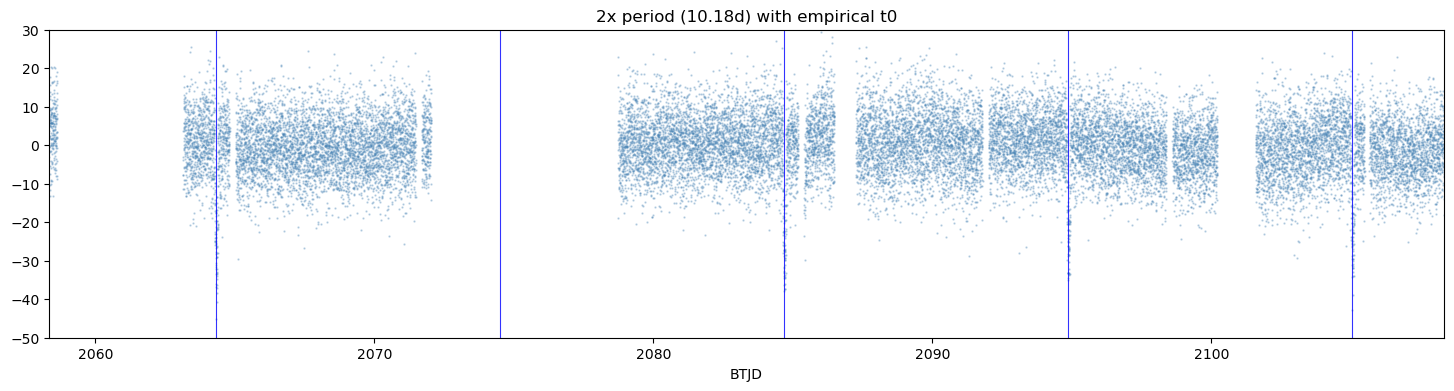

In [36]:
# find the actual first dip by looking at minimum flux in first 20 days
window = (bjd > 2058) & (bjd < 2075)
min_idx = np.argmin(flux[window])
t0_actual = bjd[window][min_idx]
print(f"Approximate first transit: {t0_actual:.4f}")

# now replot with corrected t0
fig, ax = plt.subplots(figsize=(18, 4))
ax.scatter(bjd, flux, s=0.5, alpha=0.3, color='steelblue')

for n in range(-1, 35):
    tt = t0_actual + n * det_period_days * 2  # use 2x period
    if bjd.min() <= tt <= bjd.max():
        ax.axvline(tt, color='blue', lw=0.8, alpha=0.8, linestyle='-')

ax.set_xlim(bjd.min(), bjd.min() + 50)
ax.set_ylim(-50, 30)
ax.set_xlabel('BTJD')
ax.set_title(f'2x period ({det_period_days*2:.2f}d) with empirical t0')
plt.show()